# 이용량 상위 20개 station 통합 분석

이 노트북은 이용량이 많은 station 20개를 대상으로, 원천 데이터 확인부터 전처리, 패턴 feature 생성, Ridge 학습, station별 성능 비교, 오차 진단, 최종 결론까지 한 흐름으로 정리한 통합 분석 노트입니다.

## 분석 흐름
1. 분석 대상과 사용 데이터 정리
2. station 선정 근거 설명
3. 원천 데이터 품질 점검
4. 전처리 및 데이터 분할 방식 정리
5. 패턴 기반 feature 생성 과정 설명
6. Ridge 튜닝 및 성능 비교
7. 통합 랭킹, 중요 feature, 오차 구간 해석
8. 최종 결론 정리

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_palette(['#1f4e79', '#2e8b57', '#d97a04', '#9c2f2f', '#6b4c9a'])
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = '#fbfbf8'
mpl.rcParams['axes.edgecolor'] = '#c7c7c7'
mpl.rcParams['grid.color'] = '#d9d9d9'
mpl.rcParams['font.size'] = 11
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().resolve().parents[0]
DATA_DIR = ROOT / 'Data'
STATION_META_DIR = ROOT.parent / '3조 공유폴더' / '강남구 대여소 정보 (2023~2025)'
TOP20_STATIONS = [2306, 2332, 2335, 2340, 2342, 2348, 2369, 2375, 2377, 2384, 2404, 2413, 2414, 2415, 2423, 2431, 3614, 3627, 3651, 4906]
TARGETS = ['rental_count', 'return_count']
SPLIT_ORDER = ['train', 'valid', 'test']
YEAR_TO_SPLIT = {2023: 'train', 2024: 'valid', 2025: 'test'}

def format_axis(ax, title=None, xlabel=None, ylabel=None, grid_axis='x'):
    if title is not None:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis, alpha=0.22, linestyle='--')
    sns.despine(ax=ax, left=False, bottom=False)
    return ax

def annotate_barh(ax, fmt='{:.3f}', pad=0.01):
    max_width = max((patch.get_width() for patch in ax.patches), default=0)
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width + max_width * pad, y, fmt.format(width), va='center', ha='left', fontsize=9, color='#333333')

def annotate_bar(ax, fmt='{:.0f}', pad=0.02):
    max_height = max((patch.get_height() for patch in ax.patches), default=0)
    for patch in ax.patches:
        height = patch.get_height()
        x = patch.get_x() + patch.get_width() / 2
        ax.text(x, height + max_height * pad, fmt.format(height), va='bottom', ha='center', fontsize=9, color='#333333')

def make_station_label(station_id, station_name, max_len=18):
    station_name = str(station_name)
    short_name = station_name if len(station_name) <= max_len else station_name[:max_len - 1] + '…'
    return f'{int(station_id)} | {short_name}'


## 1. 분석 대상과 사용 데이터

통합 노트는 각 station 노트에서 생성한 산출물을 다시 모아 비교합니다. 원천 시계열 데이터, 공휴일 기준표, 시간대 패턴 공식, 가중치 테이블, Ridge 튜닝 로그, 평가 지표, 예측 결과, 중요도 표, 연도별 패턴 비교표, 고오차 시점 표를 함께 사용합니다.

In [2]:
station_meta_frames = []
for year in ['2023', '2024', '2025']:
    meta_path = STATION_META_DIR / f'{year}_강남구_대여소.csv'
    meta_df = pd.read_csv(meta_path)
    meta_df['source_year'] = int(year)
    station_meta_frames.append(meta_df[['대여소번호', '대여소명', '위도', '경도', '주소', 'source_year']])
station_meta_df = pd.concat(station_meta_frames, ignore_index=True)
station_meta_df['station_id'] = station_meta_df['대여소번호'].astype(float).astype(int)
station_meta_df = station_meta_df.sort_values(['station_id', 'source_year']).drop_duplicates('station_id', keep='last')
station_meta_df = station_meta_df.rename(columns={'대여소명': 'station_name', '위도': 'latitude', '경도': 'longitude', '주소': 'address'})
station_meta_df['station_label'] = station_meta_df.apply(lambda row: make_station_label(row['station_id'], row['station_name']), axis=1)

raw_frames = []
formula_frames = []
weight_frames = []
tuning_frames = []
metric_frames = []
importance_frames = []
comparison_frames = []
error_frames = []
prediction_frames = []
holiday_frames = []

for station_id in TOP20_STATIONS:
    raw_df = pd.read_csv(DATA_DIR / f'station_{station_id}.csv')
    raw_df['station_id'] = station_id
    raw_frames.append(raw_df)

    formula_df = pd.read_csv(DATA_DIR / f'station_{station_id}_offday_hour_formulas.csv')
    formula_df['station_id'] = station_id
    formula_frames.append(formula_df)

    weight_df = pd.read_csv(DATA_DIR / f'station_{station_id}_month_weights.csv')
    weight_df['station_id'] = station_id
    weight_frames.append(weight_df)

    tuning_df = pd.read_csv(DATA_DIR / f'station_{station_id}_offday_month_ridge_tuning.csv')
    tuning_df['station_id'] = station_id
    tuning_frames.append(tuning_df)

    metric_df = pd.read_csv(DATA_DIR / f'station_{station_id}_offday_month_ridge_metrics.csv')
    metric_df['station_id'] = station_id
    metric_frames.append(metric_df)

    importance_df = pd.read_csv(DATA_DIR / f'station_{station_id}_feature_importance.csv')
    importance_df['station_id'] = station_id
    importance_frames.append(importance_df)

    comparison_df = pd.read_csv(DATA_DIR / f'station_{station_id}_year_actual_vs_regression_vs_ml.csv')
    comparison_df['station_id'] = station_id
    comparison_frames.append(comparison_df)

    error_df = pd.read_csv(DATA_DIR / f'station_{station_id}_2025_high_error_points.csv')
    error_df['station_id'] = station_id
    error_frames.append(error_df)

    pred_df = pd.read_csv(DATA_DIR / f'station_{station_id}_offday_month_ridge_predictions_long.csv')
    pred_df['station_id'] = station_id
    prediction_frames.append(pred_df)

    holiday_df = pd.read_csv(DATA_DIR / f'station_{station_id}_holiday_reference.csv')
    holiday_df['station_id'] = station_id
    holiday_frames.append(holiday_df)

raw_all_df = pd.concat(raw_frames, ignore_index=True)
formula_all_df = pd.concat(formula_frames, ignore_index=True)
weight_all_df = pd.concat(weight_frames, ignore_index=True)
tuning_all_df = pd.concat(tuning_frames, ignore_index=True)
metrics_df = pd.concat(metric_frames, ignore_index=True)
importance_all_df = pd.concat(importance_frames, ignore_index=True)
comparison_all_df = pd.concat(comparison_frames, ignore_index=True)
error_all_df = pd.concat(error_frames, ignore_index=True)
prediction_all_df = pd.concat(prediction_frames, ignore_index=True)
holiday_all_df = pd.concat(holiday_frames, ignore_index=True)

raw_all_df['time'] = pd.to_datetime(raw_all_df['time'])
raw_all_df['date'] = raw_all_df['time'].dt.normalize()
holiday_all_df['date'] = pd.to_datetime(holiday_all_df['date'])
shared_holiday_df = holiday_all_df[['date', 'holiday_name']].drop_duplicates().sort_values('date').reset_index(drop=True)
holiday_set = set(shared_holiday_df['date'])
raw_all_df['is_holiday'] = raw_all_df['date'].isin(holiday_set).astype(int)
raw_all_df['is_offday'] = ((raw_all_df['weekday'] >= 5) | (raw_all_df['is_holiday'] == 1)).astype(int)
raw_all_df['day_type'] = np.where(raw_all_df['is_offday'] == 1, 'offday', 'weekday')
raw_all_df['split'] = raw_all_df['year'].map(YEAR_TO_SPLIT)
raw_all_df = raw_all_df.merge(station_meta_df[['station_id', 'station_name', 'station_label', 'latitude', 'longitude', 'address']], on='station_id', how='left')


## 2. station 선정 근거

이번 분석에서는 단순히 이용량이 많은 station만 고른 것이 아니라, **머신러닝 예측에 적합하도록 이용자가 많은 station들 중에서 2023~2025년 시간별 패턴이 크게 벗어나지 않고 비교적 비슷하게 유지되는 station**을 우선 선정했습니다.

즉, 선정 기준은 다음 두 가지입니다.
1. 이용량이 충분히 많아 패턴이 안정적으로 관측될 것
2. 연도별 시간대 패턴이 지나치게 흔들리지 않아 학습한 패턴이 다음 해에도 재현될 것

,station_id,station_name,total_usage,mean_hourly_flow,mean_hourly_std,mean_hourly_cv
0,2377,수서역 5번출구,111233,4.2288,0.3938,0.1135
1,2335,3호선 매봉역 3번출구앞,108398,4.1208,0.3223,0.1147
2,2348,포스코사거리(기업은행),102225,3.8858,0.6554,0.1961
3,2340,삼호물산버스정류장(23370) 옆,95011,3.6119,0.4965,0.1601
4,2404,대모산입구역 4번 출구 앞,93814,3.5664,0.4481,0.1321
5,2306,압구정역 2번 출구 옆,89475,3.4014,0.4497,0.1789
6,2332,선릉역3번출구,88519,3.3651,0.3636,0.1191
7,2431,대치역 7번출구,87802,3.3378,0.5343,0.1768
8,2384,자곡사거리,86743,3.2975,0.4597,0.1527
9,2414,도곡역 아카데미스위트 앞,85664,3.2564,0.4636,0.2005


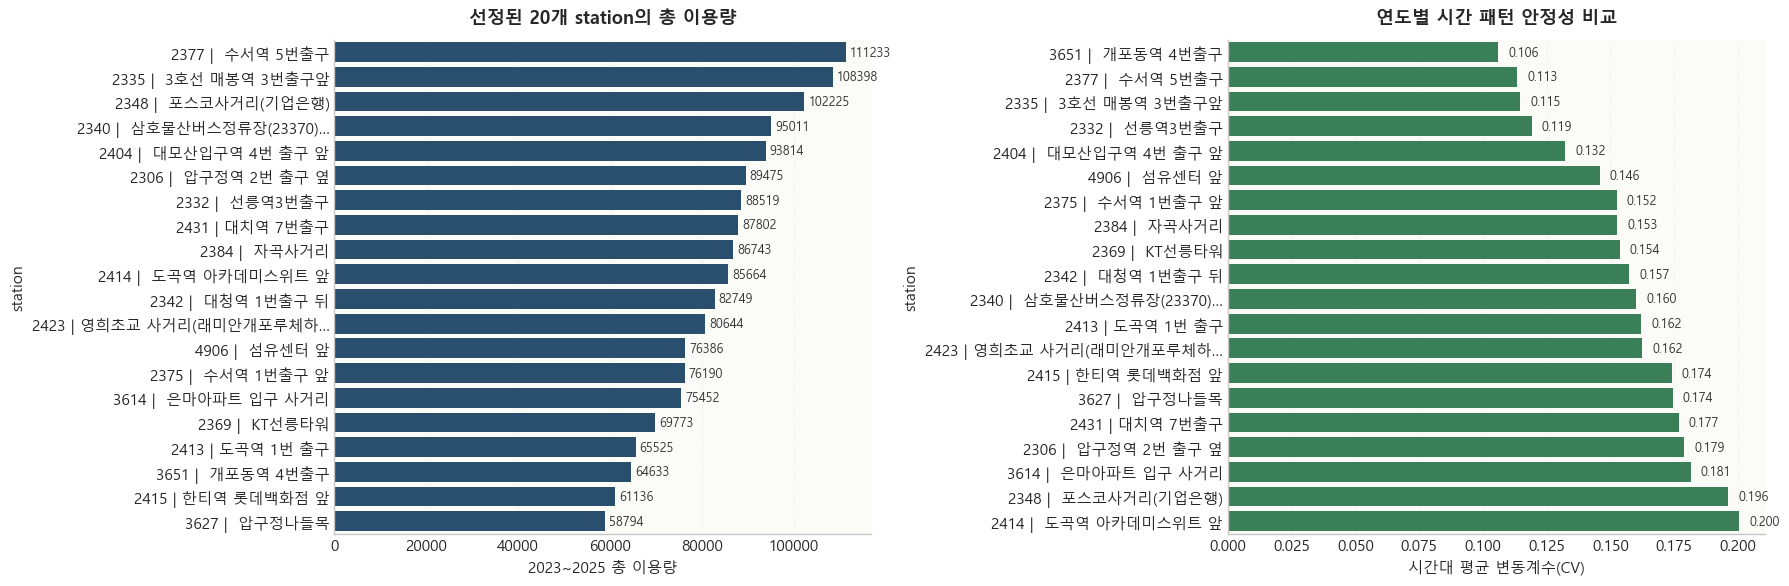

In [3]:
station_usage_df = (
    raw_all_df.groupby('station_id', as_index=False)
    .agg(
        rental_total=('rental_count', 'sum'),
        return_total=('return_count', 'sum'),
    )
)
station_usage_df['total_usage'] = station_usage_df['rental_total'] + station_usage_df['return_total']
station_usage_df = station_usage_df.sort_values('total_usage', ascending=False).reset_index(drop=True)

year_hour_profile_df = (
    raw_all_df.groupby(['station_id', 'year', 'hour'], as_index=False)[['rental_count', 'return_count']]
    .mean()
)
year_hour_profile_df['total_flow'] = year_hour_profile_df['rental_count'] + year_hour_profile_df['return_count']
pattern_stability_df = (
    year_hour_profile_df.groupby(['station_id', 'hour'], as_index=False)['total_flow']
    .agg(['mean', 'std'])
    .reset_index()
)
pattern_stability_df['cv'] = np.where(pattern_stability_df['mean'] > 0, pattern_stability_df['std'] / pattern_stability_df['mean'], 0)
pattern_stability_df = (
    pattern_stability_df.groupby('station_id', as_index=False)
    .agg(
        mean_hourly_flow=('mean', 'mean'),
        mean_hourly_std=('std', 'mean'),
        mean_hourly_cv=('cv', 'mean'),
    )
)
selection_basis_df = station_usage_df.merge(pattern_stability_df, on='station_id', how='left')
selection_basis_df = selection_basis_df.merge(station_meta_df[['station_id', 'station_name', 'station_label', 'latitude', 'longitude']], on='station_id', how='left')
selection_basis_df = selection_basis_df.sort_values(['total_usage', 'mean_hourly_cv'], ascending=[False, True]).reset_index(drop=True)
display(selection_basis_df[['station_id', 'station_name', 'total_usage', 'mean_hourly_flow', 'mean_hourly_std', 'mean_hourly_cv']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
usage_plot_df = selection_basis_df.sort_values('total_usage', ascending=False)
sns.barplot(data=usage_plot_df, x='total_usage', y='station_label', ax=axes[0], color='#1f4e79')
format_axis(axes[0], '선정된 20개 station의 총 이용량', '2023~2025 총 이용량', 'station')
annotate_barh(axes[0], fmt='{:.0f}', pad=0.008)

stability_plot_df = selection_basis_df.sort_values('mean_hourly_cv', ascending=True)
sns.barplot(data=stability_plot_df, x='mean_hourly_cv', y='station_label', ax=axes[1], color='#2e8b57')
format_axis(axes[1], '연도별 시간 패턴 안정성 비교', '시간대 평균 변동계수(CV)', 'station')
annotate_barh(axes[1], fmt='{:.3f}', pad=0.02)
plt.tight_layout()
plt.show()

top20_map = folium.Map(location=[selection_basis_df['latitude'].mean(), selection_basis_df['longitude'].mean()], zoom_start=13, tiles='CartoDB positron')
for _, row in selection_basis_df.iterrows():
    popup_html = f"<b>{row['station_name']}</b><br>station_id: {int(row['station_id'])}<br>총 이용량: {row['total_usage']:.0f}<br>평균 CV: {row['mean_hourly_cv']:.3f}"
    folium.CircleMarker(location=[row['latitude'], row['longitude']], radius=6, color='#1f4e79', fill=True, fill_color='#2e8b57', fill_opacity=0.85, popup=popup_html, tooltip=row['station_label']).add_to(top20_map)
top20_map


In [4]:
asset_summary_df = pd.DataFrame([
    {'asset': 'station 원천 csv', 'count': len(raw_frames)},
    {'asset': '공휴일 기준 csv', 'count': len(holiday_frames)},
    {'asset': '패턴 공식 csv', 'count': len(formula_frames)},
    {'asset': '가중치 csv', 'count': len(weight_frames)},
    {'asset': '튜닝 결과 csv', 'count': len(tuning_frames)},
    {'asset': '성능 지표 csv', 'count': len(metric_frames)},
    {'asset': 'feature 중요도 csv', 'count': len(importance_frames)},
    {'asset': '연도별 비교 csv', 'count': len(comparison_frames)},
    {'asset': '고오차 지점 csv', 'count': len(error_frames)},
    {'asset': '예측 long csv', 'count': len(prediction_frames)},
])
display(asset_summary_df)

scope_summary_df = pd.DataFrame([
    {'item': 'station 개수', 'value': raw_all_df['station_id'].nunique()},
    {'item': '전체 row 수', 'value': len(raw_all_df)},
    {'item': '시작 시점', 'value': raw_all_df['time'].min()},
    {'item': '종료 시점', 'value': raw_all_df['time'].max()},
    {'item': '공휴일 개수', 'value': len(shared_holiday_df)},
])
display(scope_summary_df)

station_scope_df = (
    raw_all_df.groupby('station_id', as_index=False)
    .agg(
        rows=('time', 'size'),
        rental_sum=('rental_count', 'sum'),
        return_sum=('return_count', 'sum'),
        start_time=('time', 'min'),
        end_time=('time', 'max'),
    )
    .sort_values('rental_sum', ascending=False)
)
station_scope_df = station_scope_df.merge(station_meta_df[['station_id', 'station_name', 'station_label']], on='station_id', how='left')
station_scope_df.head(10)


,asset,count
0,station 원천 csv,20
1,공휴일 기준 csv,20
2,패턴 공식 csv,20
3,가중치 csv,20
4,튜닝 결과 csv,20
5,성능 지표 csv,20
6,feature 중요도 csv,20
7,연도별 비교 csv,20
8,고오차 지점 csv,20
9,예측 long csv,20


,item,value
0,station 개수,20
1,전체 row 수,526080
2,시작 시점,2023-01-01 00:00:00
3,종료 시점,2025-12-31 23:00:00
4,공휴일 개수,56


,station_id,rows,rental_sum,return_sum,start_time,end_time,station_name,station_label
0,2335,26304,51418,56980,2023-01-01,2025-12-31 23:00:00,3호선 매봉역 3번출구앞,2335 | 3호선 매봉역 3번출구앞
1,2377,26304,50004,61229,2023-01-01,2025-12-31 23:00:00,수서역 5번출구,2377 | 수서역 5번출구
2,2404,26304,46276,47538,2023-01-01,2025-12-31 23:00:00,대모산입구역 4번 출구 앞,2404 | 대모산입구역 4번 출구 앞
3,2348,26304,45092,57133,2023-01-01,2025-12-31 23:00:00,포스코사거리(기업은행),2348 | 포스코사거리(기업은행)
4,2340,26304,44362,50649,2023-01-01,2025-12-31 23:00:00,삼호물산버스정류장(23370) 옆,2340 | 삼호물산버스정류장(23370)…
5,2306,26304,44154,45321,2023-01-01,2025-12-31 23:00:00,압구정역 2번 출구 옆,2306 | 압구정역 2번 출구 옆
6,2384,26304,42408,44335,2023-01-01,2025-12-31 23:00:00,자곡사거리,2384 | 자곡사거리
7,2431,26304,41893,45909,2023-01-01,2025-12-31 23:00:00,대치역 7번출구,2431 | 대치역 7번출구
8,2332,26304,41382,47137,2023-01-01,2025-12-31 23:00:00,선릉역3번출구,2332 | 선릉역3번출구
9,2342,26304,41368,41381,2023-01-01,2025-12-31 23:00:00,대청역 1번출구 뒤,2342 | 대청역 1번출구 뒤


## 3. 원천 데이터 품질 점검

모델 결과를 해석하기 전에 각 station 시계열이 충분한 길이를 가지는지, 결측이 많은지, 시간 중복이 있는지, 음수처럼 비정상 값이 있는지를 먼저 확인합니다.

In [5]:
quality_df = (
    raw_all_df.groupby('station_id', as_index=False)
    .agg(
        rows=('time', 'size'),
        unique_time=('time', 'nunique'),
        rental_missing=('rental_count', lambda s: int(s.isna().sum())),
        return_missing=('return_count', lambda s: int(s.isna().sum())),
        min_rental=('rental_count', 'min'),
        min_return=('return_count', 'min'),
    )
)
quality_df['duplicate_time_rows'] = quality_df['rows'] - quality_df['unique_time']
quality_df['negative_rental_exists'] = quality_df['min_rental'] < 0
quality_df['negative_return_exists'] = quality_df['min_return'] < 0
quality_df = quality_df.merge(station_meta_df[['station_id', 'station_name']], on='station_id', how='left')
quality_df.sort_values('station_id')


,station_id,rows,unique_time,rental_missing,return_missing,min_rental,min_return,duplicate_time_rows,negative_rental_exists,negative_return_exists,station_name
0,2306,26304,26304,0,0,0,0,0,False,False,압구정역 2번 출구 옆
1,2332,26304,26304,0,0,0,0,0,False,False,선릉역3번출구
2,2335,26304,26304,0,0,0,0,0,False,False,3호선 매봉역 3번출구앞
3,2340,26304,26304,0,0,0,0,0,False,False,삼호물산버스정류장(23370) 옆
4,2342,26304,26304,0,0,0,0,0,False,False,대청역 1번출구 뒤
5,2348,26304,26304,0,0,0,0,0,False,False,포스코사거리(기업은행)
6,2369,26304,26304,0,0,0,0,0,False,False,KT선릉타워
7,2375,26304,26304,0,0,0,0,0,False,False,수서역 1번출구 앞
8,2377,26304,26304,0,0,0,0,0,False,False,수서역 5번출구
9,2384,26304,26304,0,0,0,0,0,False,False,자곡사거리


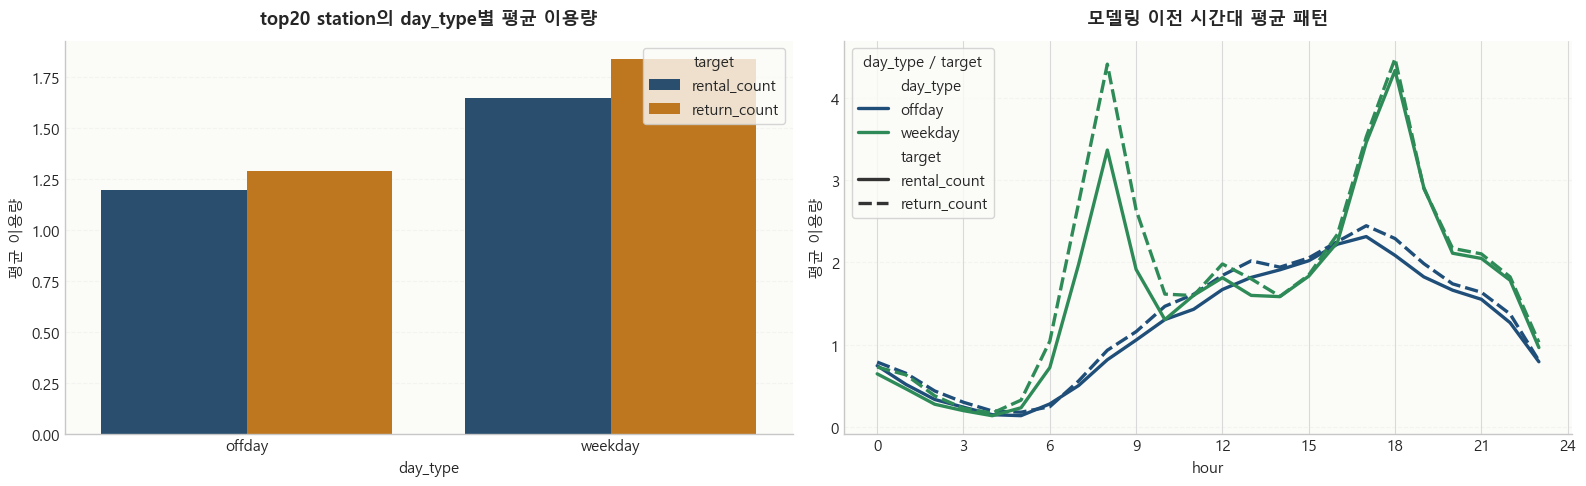

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
daily_summary = raw_all_df.groupby('day_type', as_index=False)[['rental_count', 'return_count']].mean()
daily_summary = daily_summary.melt(id_vars='day_type', var_name='target', value_name='mean_count')
sns.barplot(data=daily_summary, x='day_type', y='mean_count', hue='target', ax=axes[0], palette=['#1f4e79', '#d97a04'])
format_axis(axes[0], 'top20 station의 day_type별 평균 이용량', 'day_type', '평균 이용량', grid_axis='y')
axes[0].legend(title='target', frameon=True, loc='upper right')

hourly_profile_df = (
    raw_all_df.groupby(['day_type', 'hour'], as_index=False)[['rental_count', 'return_count']]
    .mean()
    .melt(id_vars=['day_type', 'hour'], var_name='target', value_name='mean_count')
)
sns.lineplot(data=hourly_profile_df, x='hour', y='mean_count', hue='day_type', style='target', linewidth=2.4, ax=axes[1])
format_axis(axes[1], '모델링 이전 시간대 평균 패턴', 'hour', '평균 이용량', grid_axis='y')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].legend(title='day_type / target', frameon=True, loc='upper left')
plt.tight_layout()
plt.show()


## 4. 전처리와 데이터 분할 설계

개별 station 노트는 동일한 전처리 파이프라인을 따릅니다. 시간 변수를 정리하고, 공휴일을 결합하고, 주말과 공휴일을 `offday`로 통합한 뒤, 전체 시계열을 연도 기준으로 train, valid, test로 분할합니다.

In [7]:
preprocess_example_df = raw_all_df[
    ['station_id', 'time', 'date', 'year', 'month', 'day', 'weekday', 'hour', 'is_holiday', 'is_offday', 'day_type', 'split', 'rental_count', 'return_count']
].sort_values(['station_id', 'time']).head(12)
preprocess_example_df


,station_id,time,date,year,month,day,weekday,hour,is_holiday,is_offday,day_type,split,rental_count,return_count
0,2306,2023-01-01 00:00:00,2023-01-01,2023,1,1,6,0,1,1,offday,train,0,0
1,2306,2023-01-01 01:00:00,2023-01-01,2023,1,1,6,1,1,1,offday,train,0,1
2,2306,2023-01-01 02:00:00,2023-01-01,2023,1,1,6,2,1,1,offday,train,1,0
3,2306,2023-01-01 03:00:00,2023-01-01,2023,1,1,6,3,1,1,offday,train,0,0
4,2306,2023-01-01 04:00:00,2023-01-01,2023,1,1,6,4,1,1,offday,train,0,0
5,2306,2023-01-01 05:00:00,2023-01-01,2023,1,1,6,5,1,1,offday,train,0,1
6,2306,2023-01-01 06:00:00,2023-01-01,2023,1,1,6,6,1,1,offday,train,1,0
7,2306,2023-01-01 07:00:00,2023-01-01,2023,1,1,6,7,1,1,offday,train,0,0
8,2306,2023-01-01 08:00:00,2023-01-01,2023,1,1,6,8,1,1,offday,train,0,0
9,2306,2023-01-01 09:00:00,2023-01-01,2023,1,1,6,9,1,1,offday,train,1,1


In [8]:
split_summary_df = (
    raw_all_df.groupby(['split', 'day_type'], as_index=False)
    .agg(
        rows=('time', 'size'),
        station_count=('station_id', 'nunique'),
        rental_mean=('rental_count', 'mean'),
        return_mean=('return_count', 'mean'),
    )
)
split_summary_df['split'] = pd.Categorical(split_summary_df['split'], categories=SPLIT_ORDER, ordered=True)
split_summary_df.sort_values(['split', 'day_type'])


,split,day_type,rows,station_count,rental_mean,return_mean
2,train,offday,56640,20,1.2911,1.3941
3,train,weekday,118560,20,1.7291,1.9181
4,valid,offday,57600,20,1.2688,1.3616
5,valid,weekday,118080,20,1.7358,1.9396
0,test,offday,58080,20,1.0250,1.1125
1,test,weekday,117120,20,1.4745,1.6507


## 5. 패턴 기반 feature 생성 과정

이 분석은 원천 count를 바로 Ridge에 넣지 않습니다. 먼저 `day_type`별 시간 패턴을 기본 형태로 만들고, 여기에 month, year, hour 가중치를 얹어 `base_value`, `pattern_prior`, `corrected_pattern_prior` 같은 패턴 중심 feature를 생성합니다.

In [9]:
formula_summary_df = (
    formula_all_df.groupby(['target', 'day_type'], as_index=False)
    .agg(
        station_count=('station_id', 'nunique'),
        intercept_mean=('intercept', 'mean'),
        sin_coef_mean=('sin_hour_coef', 'mean'),
        cos_coef_mean=('cos_hour_coef', 'mean'),
    )
)
display(formula_summary_df.round(4))

formula_all_df.sort_values(['target', 'day_type', 'station_id']).head(12)


,target,day_type,station_count,intercept_mean,sin_coef_mean,cos_coef_mean
0,rental_count,offday,20,1.2911,-0.9548,-0.4993
1,rental_count,weekday,20,1.7291,-0.9323,-0.6067
2,return_count,offday,20,1.3941,-0.9905,-0.5280
3,return_count,weekday,20,1.9181,-0.7532,-0.7013


,target,day_type,intercept,sin_hour_coef,cos_hour_coef,formula,station_id
1,rental_count,offday,1.4968,-1.1625,-0.7017,1.496822 + (-1.162518 * sin(2pi*hour/24)) + (-...,2306
5,rental_count,offday,1.0569,-0.7939,-0.4293,1.056850 + (-0.793908 * sin(2pi*hour/24)) + (-...,2332
9,rental_count,offday,1.2963,-1.0235,-0.5084,1.296257 + (-1.023516 * sin(2pi*hour/24)) + (-...,2335
13,rental_count,offday,1.4905,-0.8717,-0.7087,1.490466 + (-0.871654 * sin(2pi*hour/24)) + (-...,2340
17,rental_count,offday,1.4107,-1.0203,-0.4646,1.410664 + (-1.020333 * sin(2pi*hour/24)) + (-...,2342
21,rental_count,offday,0.5943,-0.4428,-0.1702,0.594280 + (-0.442832 * sin(2pi*hour/24)) + (-...,2348
25,rental_count,offday,0.7927,-0.5585,-0.2671,0.792726 + (-0.558460 * sin(2pi*hour/24)) + (-...,2369
29,rental_count,offday,0.9329,-0.7023,-0.1444,0.932910 + (-0.702308 * sin(2pi*hour/24)) + (-...,2375
33,rental_count,offday,1.6204,-1.3481,-0.6165,1.620410 + (-1.348085 * sin(2pi*hour/24)) + (-...,2377
37,rental_count,offday,1.3552,-0.7562,-0.5648,1.355226 + (-0.756203 * sin(2pi*hour/24)) + (-...,2384


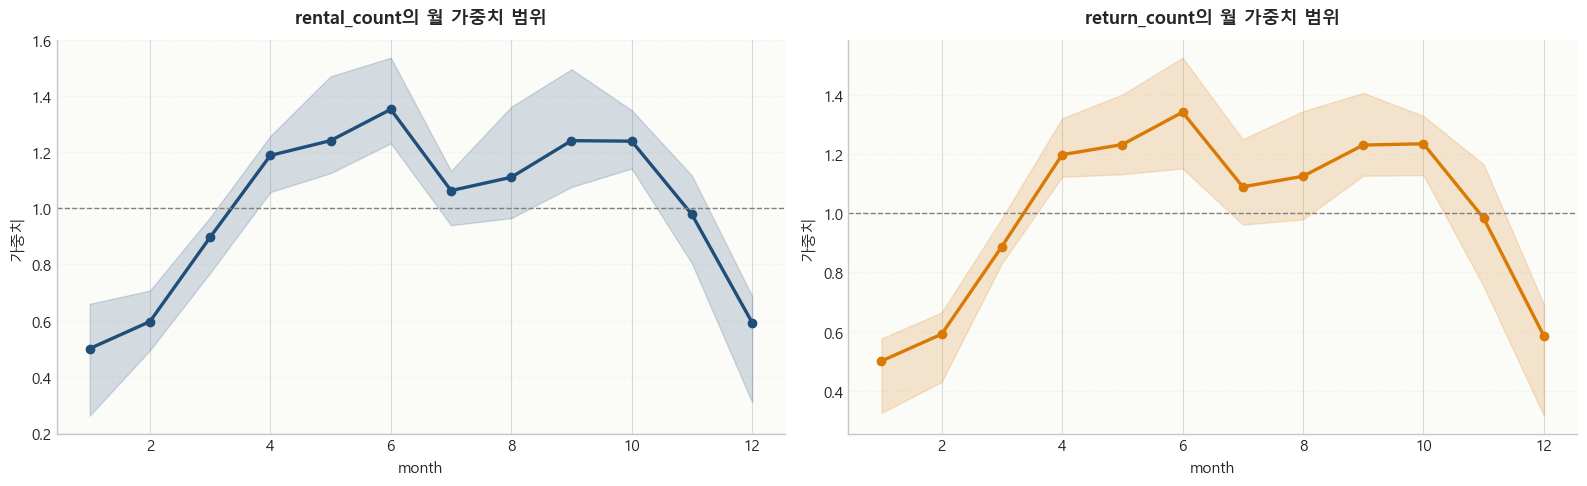

,target,month,mean_weight,min_weight,max_weight
0,rental_count,1,0.5003,0.2613,0.6597
1,rental_count,2,0.5965,0.4939,0.7069
2,rental_count,3,0.8967,0.7695,0.9677
3,rental_count,4,1.1883,1.0578,1.2576
4,rental_count,5,1.2411,1.1250,1.4703
5,rental_count,6,1.3525,1.2313,1.5363
6,rental_count,7,1.0630,0.9396,1.1335
7,rental_count,8,1.1105,0.9651,1.3614
8,rental_count,9,1.2409,1.0758,1.4954
9,rental_count,10,1.2392,1.1416,1.3494


In [10]:
month_weight_df = weight_all_df[weight_all_df['weight_type'] == 'month_weight'].copy()
month_weight_summary_df = (
    month_weight_df.groupby(['target', 'key'], as_index=False)
    .agg(
        mean_weight=('value', 'mean'),
        min_weight=('value', 'min'),
        max_weight=('value', 'max'),
    )
    .rename(columns={'key': 'month'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for ax, target in zip(axes, TARGETS):
    sub = month_weight_summary_df[month_weight_summary_df['target'] == target]
    color = '#1f4e79' if target == 'rental_count' else '#d97a04'
    ax.plot(sub['month'], sub['mean_weight'], marker='o', linewidth=2.4, color=color)
    ax.fill_between(sub['month'], sub['min_weight'], sub['max_weight'], alpha=0.18, color=color)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    format_axis(ax, f'{target}의 월 가중치 범위', 'month', '가중치', grid_axis='y')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

month_weight_summary_df.round(4)


### year_weight와 hour_weight 해석

월 가중치와 마찬가지로 실제 모델에는 `year_weight`, `hour_weight`도 함께 사용됩니다.

- `year_weight`: 특정 연도의 전체적인 수준 차이를 보정하는 값
- `hour_weight`: 기본 패턴식만으로 설명되지 않는 세부 시간대 보정을 반영하는 값

특히 `year_weight`는 **해당 연도의 실제 데이터를 보고 계산되는 값**이기 때문에, 완전히 새로운 연도에 대해 사전에 정확한 값을 알 수 없습니다. 즉, 새로운 연도의 데이터를 일부 확보한 뒤 다시 weight를 갱신하거나 모델을 재학습하는 과정이 필요합니다.

따라서 현재 구조에서 `year_weight`는 장기 미래를 미리 고정적으로 예측하는 변수라기보다, 해당 연도의 수준 변화를 반영하기 위한 사후적 보정값에 가깝습니다.

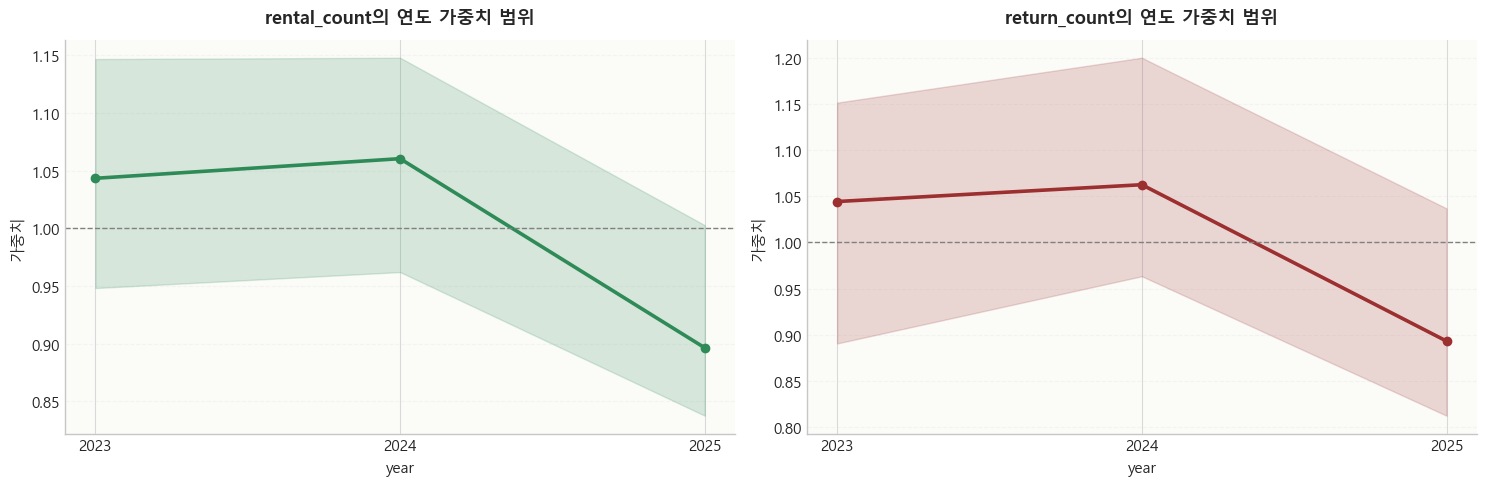

,target,year,mean_weight,min_weight,max_weight
0,rental_count,2023,1.0433,0.9481,1.1468
1,rental_count,2024,1.0604,0.9620,1.1479
2,rental_count,2025,0.8963,0.8374,1.0027
3,return_count,2023,1.0442,0.8908,1.1512
4,return_count,2024,1.0624,0.9635,1.1998
5,return_count,2025,0.8933,0.8127,1.0368


In [11]:
year_weight_df = weight_all_df[weight_all_df['weight_type'] == 'year_weight'].copy()
year_weight_summary_df = (
    year_weight_df.groupby(['target', 'key'], as_index=False)
    .agg(
        mean_weight=('value', 'mean'),
        min_weight=('value', 'min'),
        max_weight=('value', 'max'),
    )
    .rename(columns={'key': 'year'})
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
for ax, target in zip(axes, TARGETS):
    sub = year_weight_summary_df[year_weight_summary_df['target'] == target].copy().sort_values('year')
    color = '#2e8b57' if target == 'rental_count' else '#9c2f2f'
    ax.plot(sub['year'], sub['mean_weight'], marker='o', linewidth=2.6, color=color)
    ax.fill_between(sub['year'], sub['min_weight'], sub['max_weight'], alpha=0.18, color=color)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    format_axis(ax, f'{target}의 연도 가중치 범위', 'year', '가중치', grid_axis='y')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

year_weight_summary_df.round(4)


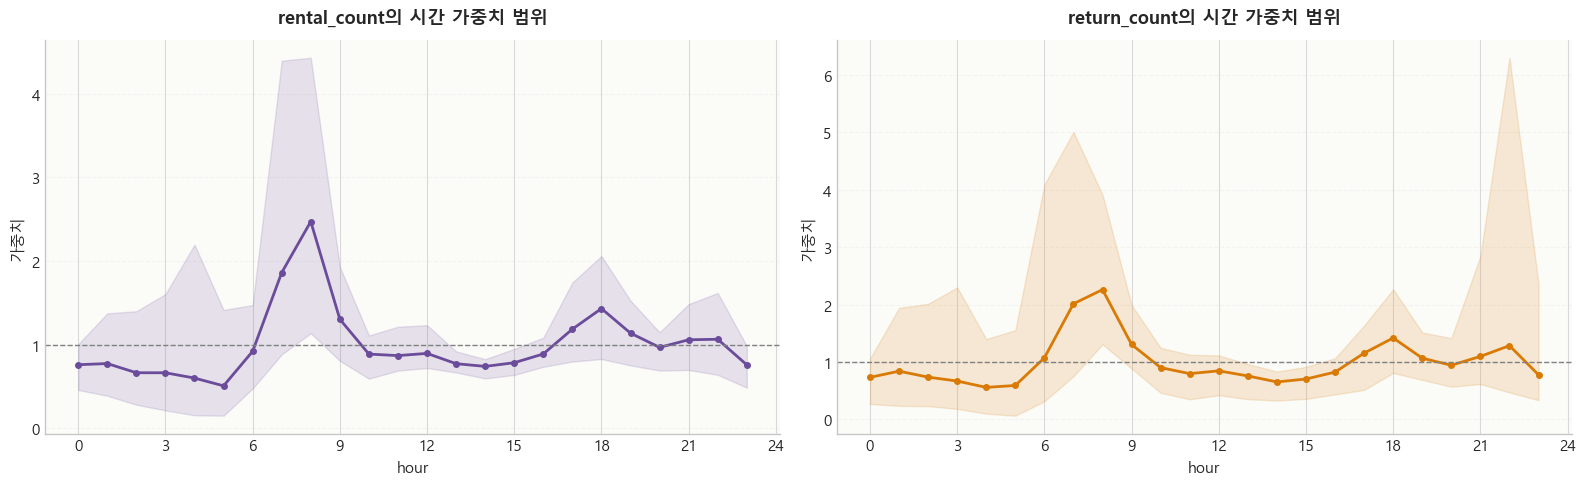

,target,hour,mean_weight,min_weight,max_weight
0,rental_count,0,0.7618,0.4597,1.0066
1,rental_count,1,0.7754,0.3908,1.3749
2,rental_count,2,0.6658,0.2837,1.4010
3,rental_count,3,0.6654,0.2159,1.6051
4,rental_count,4,0.6021,0.1578,2.1961
5,rental_count,5,0.5091,0.1527,1.4160
6,rental_count,6,0.9217,0.4774,1.4738
7,rental_count,7,1.8615,0.8844,4.3942
8,rental_count,8,2.4723,1.1380,4.4294
9,rental_count,9,1.3050,0.8080,1.9297


In [12]:
hour_weight_df = weight_all_df[weight_all_df['weight_type'] == 'hour_weight'].copy()
hour_weight_summary_df = (
    hour_weight_df.groupby(['target', 'key'], as_index=False)
    .agg(
        mean_weight=('value', 'mean'),
        min_weight=('value', 'min'),
        max_weight=('value', 'max'),
    )
    .rename(columns={'key': 'hour'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for ax, target in zip(axes, TARGETS):
    sub = hour_weight_summary_df[hour_weight_summary_df['target'] == target].copy().sort_values('hour')
    color = '#6b4c9a' if target == 'rental_count' else '#d97a04'
    ax.plot(sub['hour'], sub['mean_weight'], marker='o', markersize=4, linewidth=2.0, color=color)
    ax.fill_between(sub['hour'], sub['min_weight'], sub['max_weight'], alpha=0.15, color=color)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    format_axis(ax, f'{target}의 시간 가중치 범위', 'hour', '가중치', grid_axis='y')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

hour_weight_summary_df.round(4)


## 6. 모델 선정 이유

이번 분석에서는 `pattern feature + Ridge 회귀` 구조를 선택했습니다. 선정 이유는 다음과 같습니다.

1. **해석 가능성**: 대여/반납량이 어떤 시간 패턴과 가중치에 의해 설명되는지 비교적 명확하게 볼 수 있습니다.
2. **데이터 규모 적합성**: station별로 데이터를 나누어 학습할 때, 지나치게 복잡한 모델보다 안정적으로 학습됩니다.
3. **과적합 제어**: Ridge의 `alpha`를 통해 feature 계수를 조절할 수 있어 station별 변동에 과하게 맞추는 것을 줄일 수 있습니다.
4. **현재 목적과의 적합성**: 이번 단계의 핵심은 `rental_count`, `return_count`를 예측하고 station 간 패턴을 비교하는 것이므로, 고성능 블랙박스 모델보다 구조가 단순하고 비교가 쉬운 모델이 더 적절했습니다.

즉, 이번 모델은 최고 복잡도의 예측기라기보다, **시간 패턴을 보존하면서 station별 차이를 해석 가능하게 비교하기 위한 기준 모델**로 선택한 것입니다.

## 7. Ridge 튜닝과 평가

station별, target별로 train 구간에서 패턴 구조를 학습하고 valid 구간에서 Ridge alpha를 고른 뒤, 같은 설정을 2025 test 구간에 적용해 최종 성능을 평가합니다.

In [13]:
best_alpha_df = (
    tuning_all_df.sort_values(['station_id', 'target', 'rmse'])
    .groupby(['station_id', 'target'], as_index=False)
    .first()
)
display(best_alpha_df[['station_id', 'target', 'alpha', 'rmse', 'mae', 'r2']].round(4))

alpha_dist_df = (
    best_alpha_df.groupby(['target', 'alpha'], as_index=False)
    .size()
    .rename(columns={'size': 'station_count'})
)
alpha_dist_df


,station_id,target,alpha,rmse,mae,r2
0,2306,rental_count,100.0000,1.6549,1.1608,0.3770
1,2306,return_count,0.0010,1.7203,1.1495,0.5577
2,2332,rental_count,10.0000,1.5037,1.1007,0.3987
3,2332,return_count,0.0010,1.6331,1.1735,0.4680
4,2335,rental_count,0.0010,1.8079,1.2319,0.5365
5,2335,return_count,10.0000,1.8421,1.2838,0.5397
6,2340,rental_count,0.0010,1.7013,1.2041,0.3970
7,2340,return_count,100.0000,1.7442,1.2557,0.4382
8,2342,rental_count,0.0010,1.4614,1.0430,0.3825
9,2342,return_count,10.0000,1.4859,1.0689,0.3749


,target,alpha,station_count
0,rental_count,0.0010,10
1,rental_count,1.0000,2
2,rental_count,10.0000,1
3,rental_count,100.0000,2
4,rental_count,"1,000.0000",5
5,return_count,0.0010,6
6,return_count,10.0000,4
7,return_count,100.0000,7
8,return_count,"1,000.0000",3


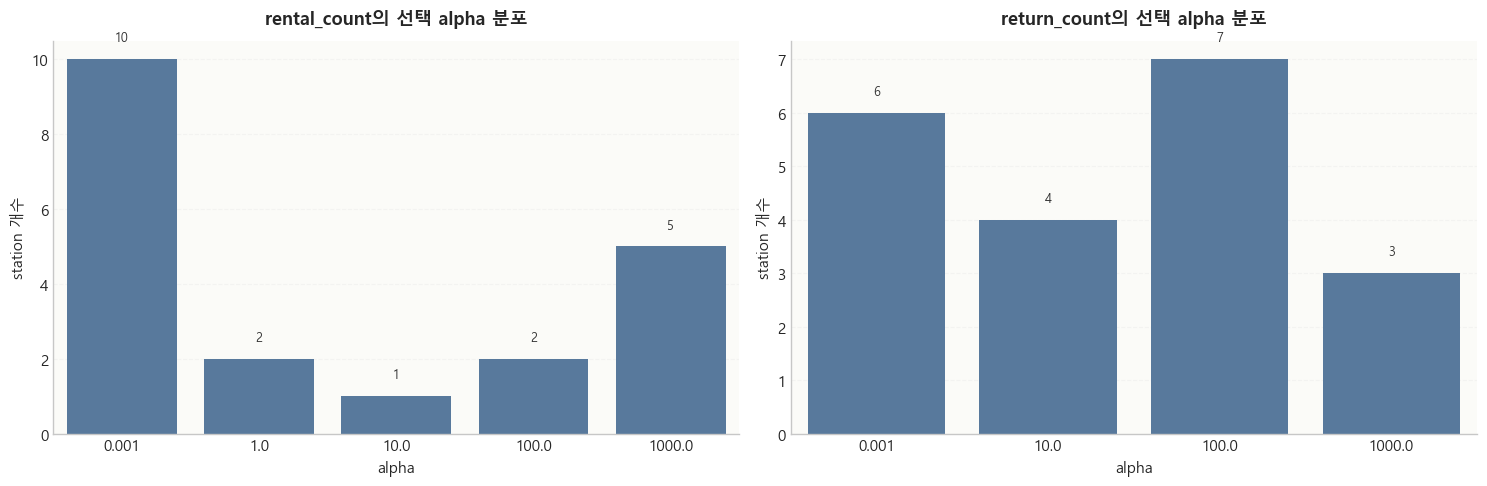

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, target in zip(axes, TARGETS):
    sub = alpha_dist_df[alpha_dist_df['target'] == target].copy()
    sub['alpha_label'] = sub['alpha'].astype(str)
    sns.barplot(data=sub, x='alpha_label', y='station_count', ax=ax, color='#4C78A8')
    format_axis(ax, f'{target}의 선택 alpha 분포', 'alpha', 'station 개수', grid_axis='y')
    annotate_bar(ax, fmt='{:.0f}', pad=0.04)
plt.tight_layout()
plt.show()


## 8. station별 성능 비교

이 절에서는 split별 RMSE, MAE, R^2를 비교하고, 마지막에는 두 target의 test R^2 평균으로 통합 랭킹을 만듭니다.

In [15]:
metric_summary_df = (
    metrics_df.groupby(['target', 'split'], as_index=False)
    .agg(
        rmse_mean=('rmse', 'mean'),
        mae_mean=('mae', 'mean'),
        r2_mean=('r2', 'mean'),
        r2_min=('r2', 'min'),
        r2_max=('r2', 'max'),
    )
)
metric_summary_df['split'] = pd.Categorical(metric_summary_df['split'], categories=SPLIT_ORDER, ordered=True)
metric_summary_df.sort_values(['target', 'split']).round(4)


,target,split,rmse_mean,mae_mean,r2_mean,r2_min,r2_max
1,bike_change_from_predictions,train,1.7775,1.2166,0.1616,0.0058,0.6130
2,bike_change_from_predictions,valid,1.8212,1.2502,0.1826,-0.0660,0.6550
0,bike_change_from_predictions,test,1.7200,1.1706,0.1551,-0.0790,0.6229
4,rental_count,train,1.6138,1.1194,0.3754,0.2786,0.5636
5,rental_count,valid,1.5825,1.1035,0.3915,0.2647,0.6640
3,rental_count,test,1.4124,0.9889,0.3498,0.2040,0.5848
7,return_count,train,1.6911,1.1722,0.4206,0.3100,0.6408
8,return_count,valid,1.6624,1.1649,0.4328,0.2880,0.6702
6,return_count,test,1.5161,1.0562,0.3781,0.2191,0.6441


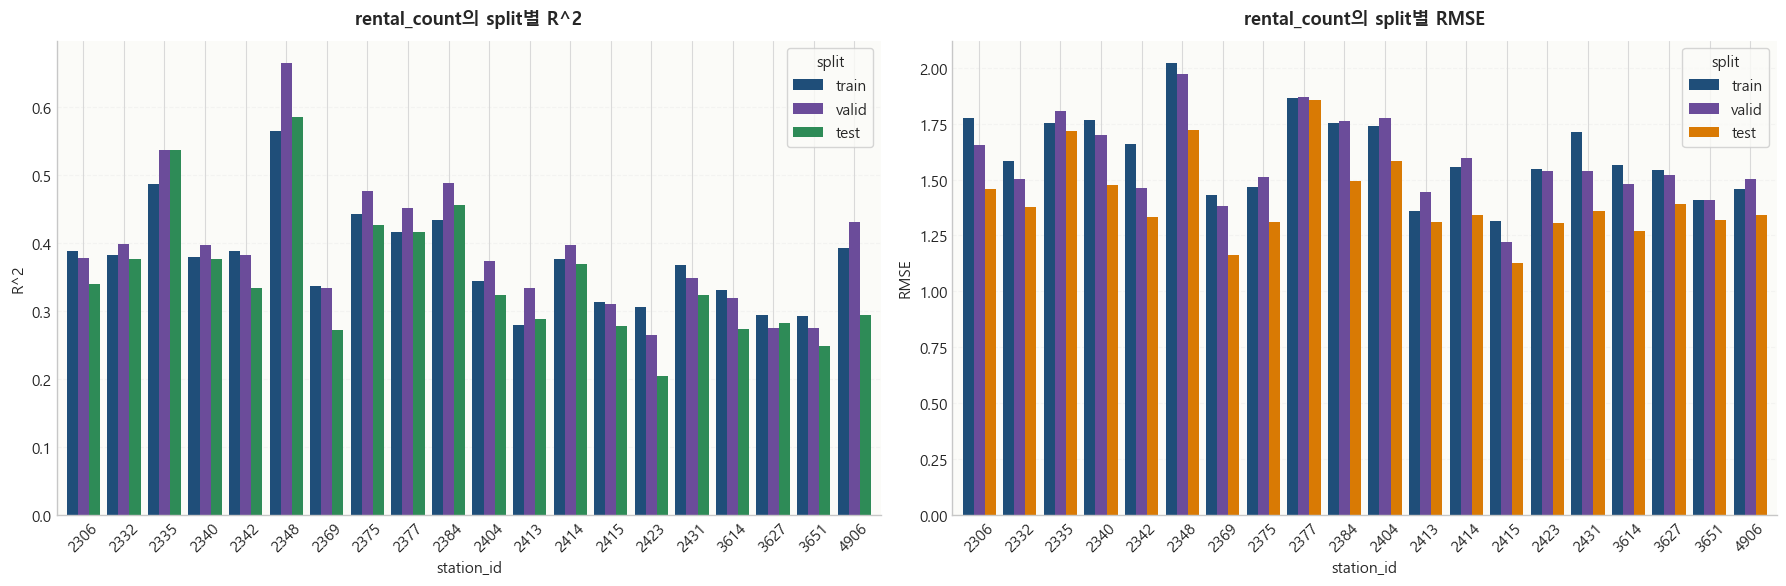

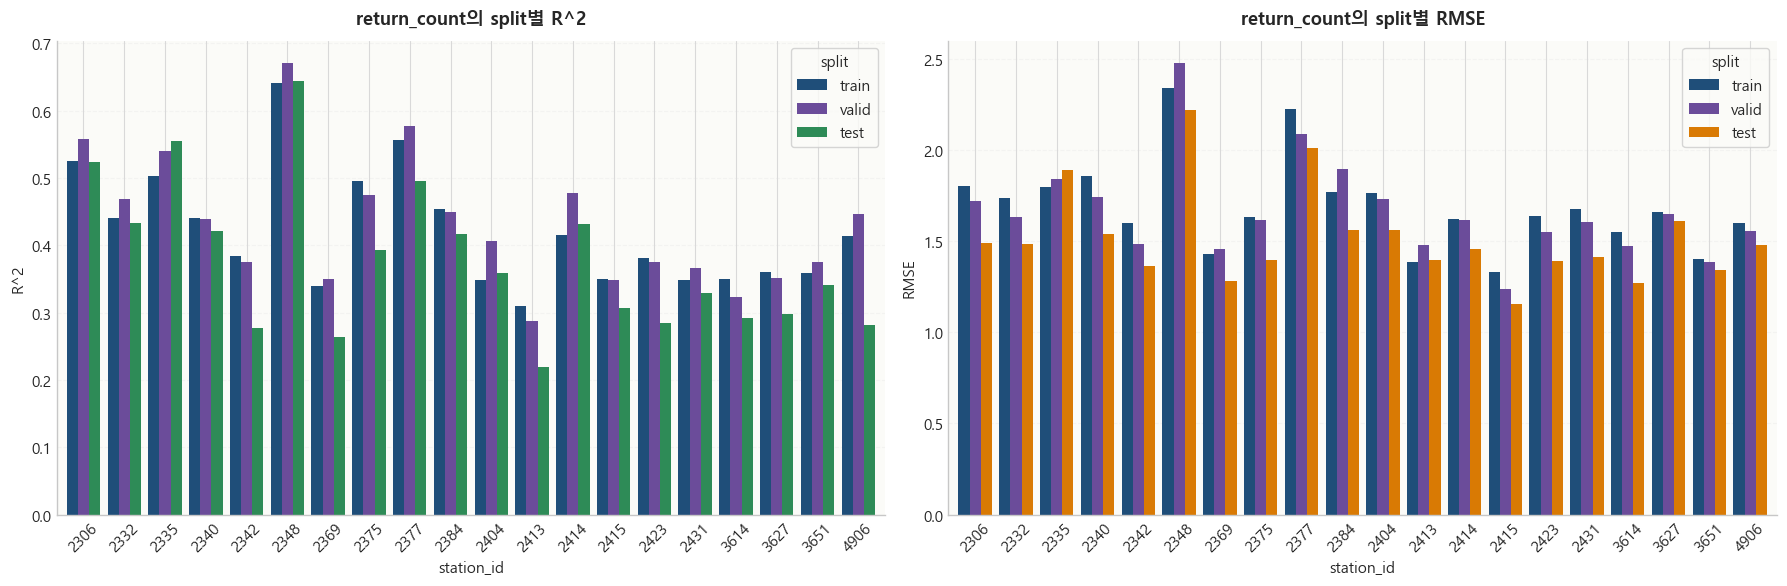

In [16]:
for target in TARGETS:
    view = metrics_df[metrics_df['target'] == target].copy()
    pivot_r2 = view.pivot(index='station_id', columns='split', values='r2').reindex(TOP20_STATIONS)
    pivot_rmse = view.pivot(index='station_id', columns='split', values='rmse').reindex(TOP20_STATIONS)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    pivot_r2[SPLIT_ORDER].plot(kind='bar', ax=axes[0], color=['#1f4e79', '#6b4c9a', '#2e8b57'], width=0.82)
    format_axis(axes[0], f'{target}의 split별 R^2', 'station_id', 'R^2', grid_axis='y')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title='split', frameon=True, loc='upper right')
    pivot_rmse[SPLIT_ORDER].plot(kind='bar', ax=axes[1], color=['#1f4e79', '#6b4c9a', '#d97a04'], width=0.82)
    format_axis(axes[1], f'{target}의 split별 RMSE', 'station_id', 'RMSE', grid_axis='y')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='split', frameon=True, loc='upper right')
    plt.tight_layout()
    plt.show()


In [17]:
test_metric_df = metrics_df[(metrics_df['split'] == 'test') & (metrics_df['target'].isin(TARGETS))].copy()
r2_df = (
    test_metric_df.pivot_table(index='station_id', columns='target', values='r2', aggfunc='mean')
    .reset_index()
)
rmse_df = (
    test_metric_df.pivot_table(index='station_id', columns='target', values='rmse', aggfunc='mean')
    .reset_index()
    .rename(columns={'rental_count': 'rental_rmse', 'return_count': 'return_rmse'})
)
mae_df = (
    test_metric_df.pivot_table(index='station_id', columns='target', values='mae', aggfunc='mean')
    .reset_index()
    .rename(columns={'rental_count': 'rental_mae', 'return_count': 'return_mae'})
)
ranking_df = r2_df.merge(rmse_df, on='station_id').merge(mae_df, on='station_id')
ranking_df['combined_test_r2'] = ranking_df[['rental_count', 'return_count']].mean(axis=1)
ranking_df['combined_test_rmse'] = ranking_df[['rental_rmse', 'return_rmse']].mean(axis=1)
ranking_df['combined_test_mae'] = ranking_df[['rental_mae', 'return_mae']].mean(axis=1)
ranking_df = ranking_df.sort_values('combined_test_r2', ascending=False).reset_index(drop=True)
ranking_df = ranking_df.merge(station_meta_df[['station_id', 'station_name', 'station_label', 'latitude', 'longitude']], on='station_id', how='left')
ranking_df.index = ranking_df.index + 1
ranking_df.to_csv(DATA_DIR / 'top20_station_combined_test_r2_ranking.csv', index_label='rank', encoding='utf-8-sig')
ranking_df


,station_id,rental_count,return_count,rental_rmse,return_rmse,rental_mae,return_mae,combined_test_r2,combined_test_rmse,combined_test_mae,station_name,station_label,latitude,longitude
1,2348,0.5848,0.6441,1.7215,2.2219,1.0214,1.2797,0.6144,1.9717,1.1505,포스코사거리(기업은행),2348 | 포스코사거리(기업은행),37.5072,127.0569
2,2335,0.5367,0.5552,1.7196,1.8927,1.1629,1.2819,0.5460,1.8061,1.2224,3호선 매봉역 3번출구앞,2335 | 3호선 매봉역 3번출구앞,37.4868,127.0468
3,2377,0.4155,0.4957,1.8552,2.0133,1.2471,1.4052,0.4556,1.9343,1.3262,수서역 5번출구,2377 | 수서역 5번출구,37.4874,127.1023
4,2384,0.4551,0.4159,1.4937,1.5597,1.0598,1.0711,0.4355,1.5267,1.0654,자곡사거리,2384 | 자곡사거리,37.4760,127.1059
5,2306,0.3398,0.5235,1.4563,1.4913,1.0125,0.9917,0.4316,1.4738,1.0021,압구정역 2번 출구 옆,2306 | 압구정역 2번 출구 옆,37.5271,127.0287
6,2375,0.4257,0.3922,1.3082,1.3978,0.8794,1.0040,0.4089,1.3530,0.9417,수서역 1번출구 앞,2375 | 수서역 1번출구 앞,37.4874,127.1010
7,2332,0.3764,0.4328,1.3788,1.4866,0.9867,1.0716,0.4046,1.4327,1.0291,선릉역3번출구,2332 | 선릉역3번출구,37.5040,127.0491
8,2414,0.3686,0.4314,1.3425,1.4572,0.9557,1.0536,0.4000,1.3999,1.0046,도곡역 아카데미스위트 앞,2414 | 도곡역 아카데미스위트 앞,37.4890,127.0518
9,2340,0.3758,0.4206,1.4763,1.5403,1.0656,1.1221,0.3982,1.5083,1.0938,삼호물산버스정류장(23370) 옆,2340 | 삼호물산버스정류장(23370)…,37.4775,127.0452
10,2404,0.3231,0.3581,1.5816,1.5613,1.1360,1.1262,0.3406,1.5715,1.1311,대모산입구역 4번 출구 앞,2404 | 대모산입구역 4번 출구 앞,37.4918,127.0732


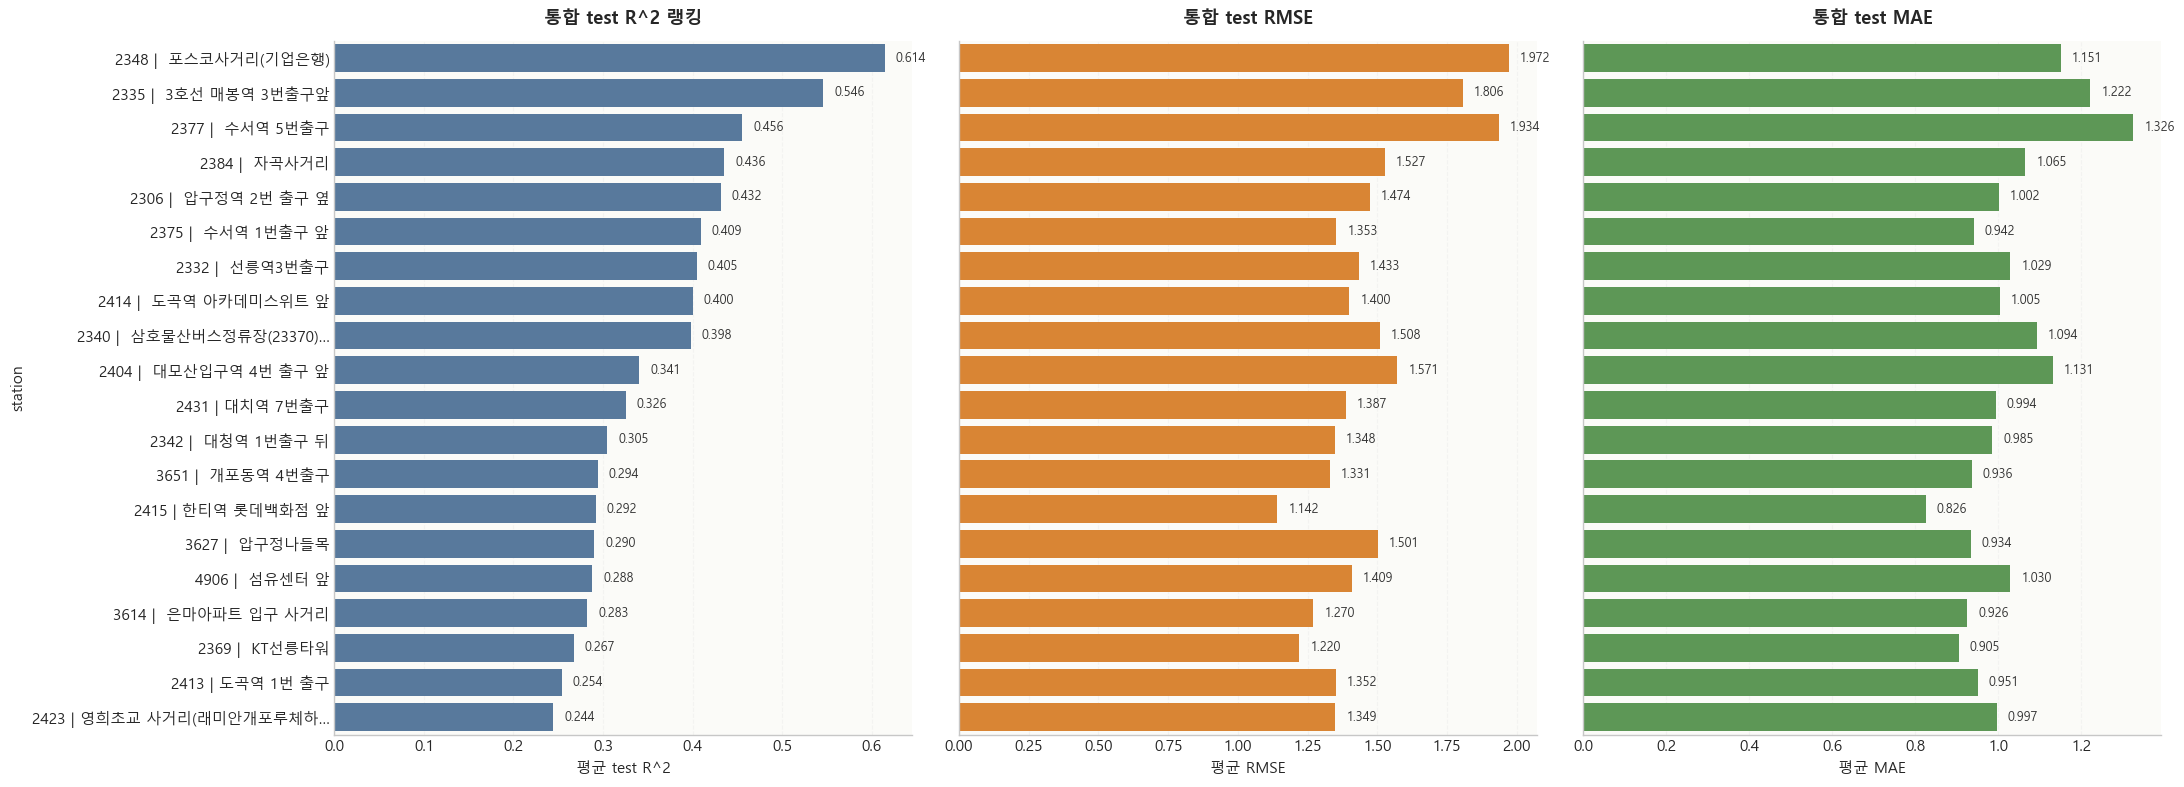

,rank,station_id,station_name,rental_count,return_count,combined_test_r2,combined_test_rmse,combined_test_mae
0,1,2348,포스코사거리(기업은행),0.5848,0.6441,0.6144,1.9717,1.1505
1,2,2335,3호선 매봉역 3번출구앞,0.5367,0.5552,0.5460,1.8061,1.2224
2,3,2377,수서역 5번출구,0.4155,0.4957,0.4556,1.9343,1.3262
3,4,2384,자곡사거리,0.4551,0.4159,0.4355,1.5267,1.0654
4,5,2306,압구정역 2번 출구 옆,0.3398,0.5235,0.4316,1.4738,1.0021
5,6,2375,수서역 1번출구 앞,0.4257,0.3922,0.4089,1.3530,0.9417
6,7,2332,선릉역3번출구,0.3764,0.4328,0.4046,1.4327,1.0291
7,8,2414,도곡역 아카데미스위트 앞,0.3686,0.4314,0.4000,1.3999,1.0046
8,9,2340,삼호물산버스정류장(23370) 옆,0.3758,0.4206,0.3982,1.5083,1.0938
9,10,2404,대모산입구역 4번 출구 앞,0.3231,0.3581,0.3406,1.5715,1.1311


In [18]:
plot_df = ranking_df.reset_index().rename(columns={'index': 'rank'})
fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)
sns.barplot(data=plot_df, x='combined_test_r2', y='station_label', ax=axes[0], color='#4C78A8')
format_axis(axes[0], '통합 test R^2 랭킹', '평균 test R^2', 'station')
annotate_barh(axes[0], fmt='{:.3f}', pad=0.02)

sns.barplot(data=plot_df, x='combined_test_rmse', y='station_label', ax=axes[1], color='#F58518')
format_axis(axes[1], '통합 test RMSE', '평균 RMSE', 'station')
annotate_barh(axes[1], fmt='{:.3f}', pad=0.02)

sns.barplot(data=plot_df, x='combined_test_mae', y='station_label', ax=axes[2], color='#54A24B')
format_axis(axes[2], '통합 test MAE', '평균 MAE', 'station')
annotate_barh(axes[2], fmt='{:.3f}', pad=0.02)
plt.tight_layout()
plt.show()

plot_df[['rank', 'station_id', 'station_name', 'rental_count', 'return_count', 'combined_test_r2', 'combined_test_rmse', 'combined_test_mae']]


## 9. 상위 6개 station 심화 분석

통합 test R^2 기준으로 가장 성능이 좋은 상위 6개 station을 별도로 선정해, 성능 구성, 주요 feature, 연도별 패턴 재현력, 오차 특성을 더 자세히 살펴봅니다.

In [19]:
top6_station_ids = ranking_df.head(6)['station_id'].astype(int).tolist()
top6_summary_df = ranking_df[ranking_df['station_id'].isin(top6_station_ids)].copy()
top6_summary_df = top6_summary_df.set_index('station_id').loc[top6_station_ids].reset_index()
top6_summary_df


,station_id,rental_count,return_count,rental_rmse,return_rmse,rental_mae,return_mae,combined_test_r2,combined_test_rmse,combined_test_mae,station_name,station_label,latitude,longitude
0,2348,0.5848,0.6441,1.7215,2.2219,1.0214,1.2797,0.6144,1.9717,1.1505,포스코사거리(기업은행),2348 | 포스코사거리(기업은행),37.5072,127.0569
1,2335,0.5367,0.5552,1.7196,1.8927,1.1629,1.2819,0.5460,1.8061,1.2224,3호선 매봉역 3번출구앞,2335 | 3호선 매봉역 3번출구앞,37.4868,127.0468
2,2377,0.4155,0.4957,1.8552,2.0133,1.2471,1.4052,0.4556,1.9343,1.3262,수서역 5번출구,2377 | 수서역 5번출구,37.4874,127.1023
3,2384,0.4551,0.4159,1.4937,1.5597,1.0598,1.0711,0.4355,1.5267,1.0654,자곡사거리,2384 | 자곡사거리,37.4760,127.1059
4,2306,0.3398,0.5235,1.4563,1.4913,1.0125,0.9917,0.4316,1.4738,1.0021,압구정역 2번 출구 옆,2306 | 압구정역 2번 출구 옆,37.5271,127.0287
5,2375,0.4257,0.3922,1.3082,1.3978,0.8794,1.0040,0.4089,1.3530,0.9417,수서역 1번출구 앞,2375 | 수서역 1번출구 앞,37.4874,127.1010


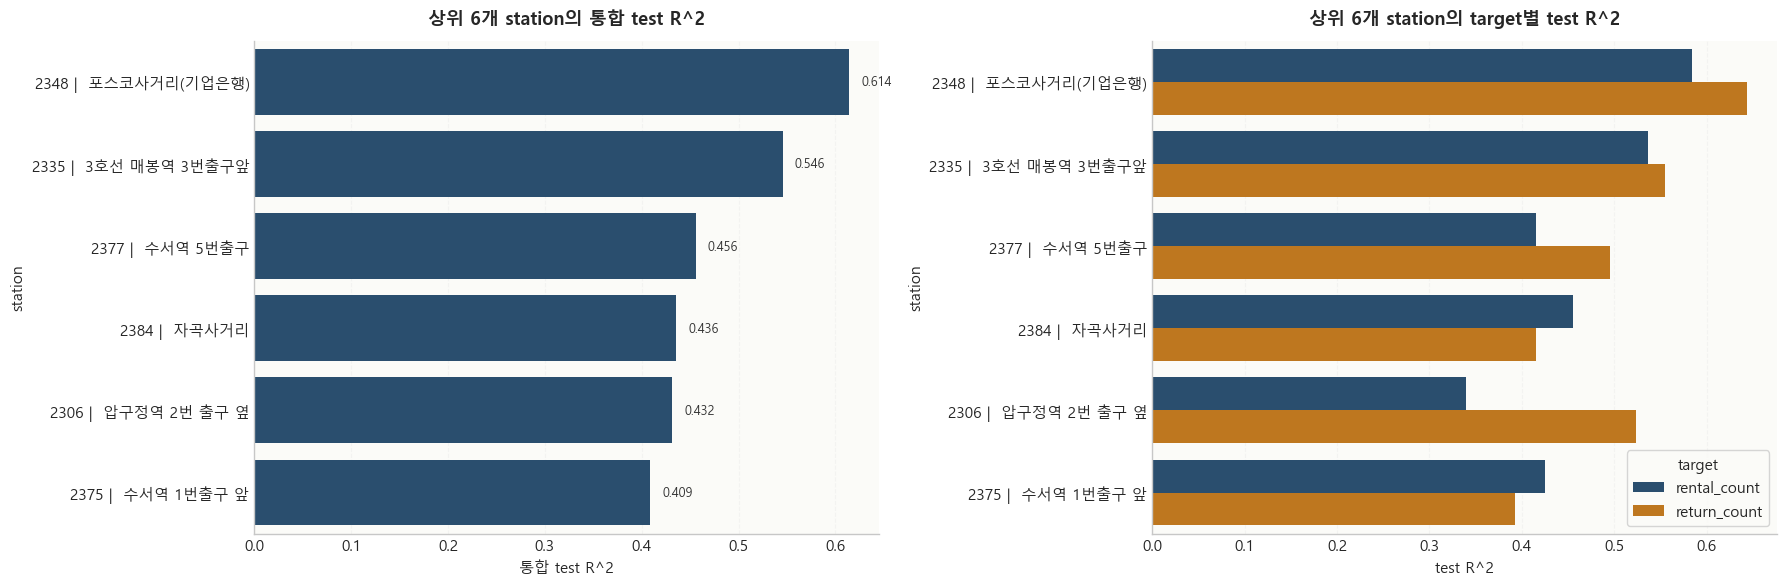

In [20]:
top6_plot_df = top6_summary_df.copy()
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=top6_plot_df, x='combined_test_r2', y='station_label', ax=axes[0], color='#1f4e79')
format_axis(axes[0], '상위 6개 station의 통합 test R^2', '통합 test R^2', 'station')
annotate_barh(axes[0], fmt='{:.3f}', pad=0.02)

top6_target_df = top6_plot_df.melt(id_vars=['station_id', 'station_name', 'station_label', 'latitude', 'longitude'], value_vars=['rental_count', 'return_count'], var_name='target', value_name='test_r2')
sns.barplot(data=top6_target_df, x='test_r2', y='station_label', hue='target', ax=axes[1], palette=['#1f4e79', '#d97a04'])
format_axis(axes[1], '상위 6개 station의 target별 test R^2', 'test R^2', 'station')
axes[1].legend(title='target', frameon=True, loc='lower right')
plt.tight_layout()
plt.show()

top6_map = folium.Map(location=[top6_plot_df['latitude'].mean(), top6_plot_df['longitude'].mean()], zoom_start=13, tiles='CartoDB positron')
for _, row in top6_plot_df.iterrows():
    popup_html = f"<b>{row['station_name']}</b><br>station_id: {int(row['station_id'])}<br>통합 test R^2: {row['combined_test_r2']:.3f}"
    folium.Marker(location=[row['latitude'], row['longitude']], popup=popup_html, tooltip=row['station_label'], icon=folium.Icon(color='blue', icon='info-sign')).add_to(top6_map)
top6_map


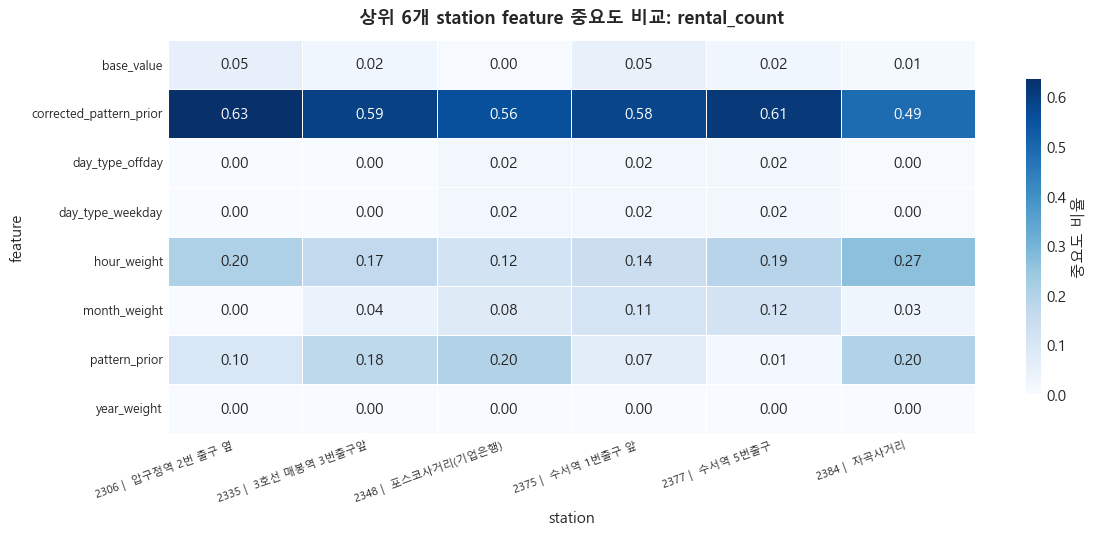

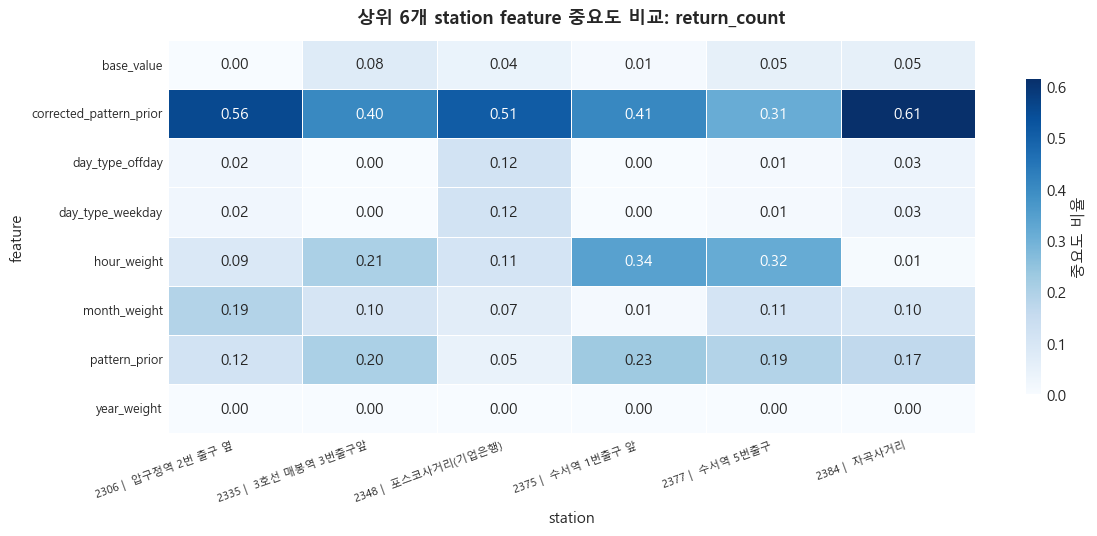

In [21]:
top6_importance_df = importance_all_df[importance_all_df['station_id'].isin(top6_station_ids)].copy()
for target in TARGETS:
    target_df = top6_importance_df[top6_importance_df['target'] == target].copy()
    target_df = target_df.merge(station_meta_df[['station_id', 'station_label']], on='station_id', how='left')
    pivot_df = target_df.pivot(index='feature', columns='station_label', values='importance_ratio')
    plt.figure(figsize=(12, 5.5))
    sns.heatmap(pivot_df, annot=True, fmt='.2f', cmap='Blues', linewidths=0.4, linecolor='white', cbar_kws={'shrink': 0.8, 'label': '중요도 비율'})
    plt.title(f'상위 6개 station feature 중요도 비교: {target}', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('station')
    plt.ylabel('feature')
    plt.xticks(rotation=20, ha='right', fontsize=8)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()


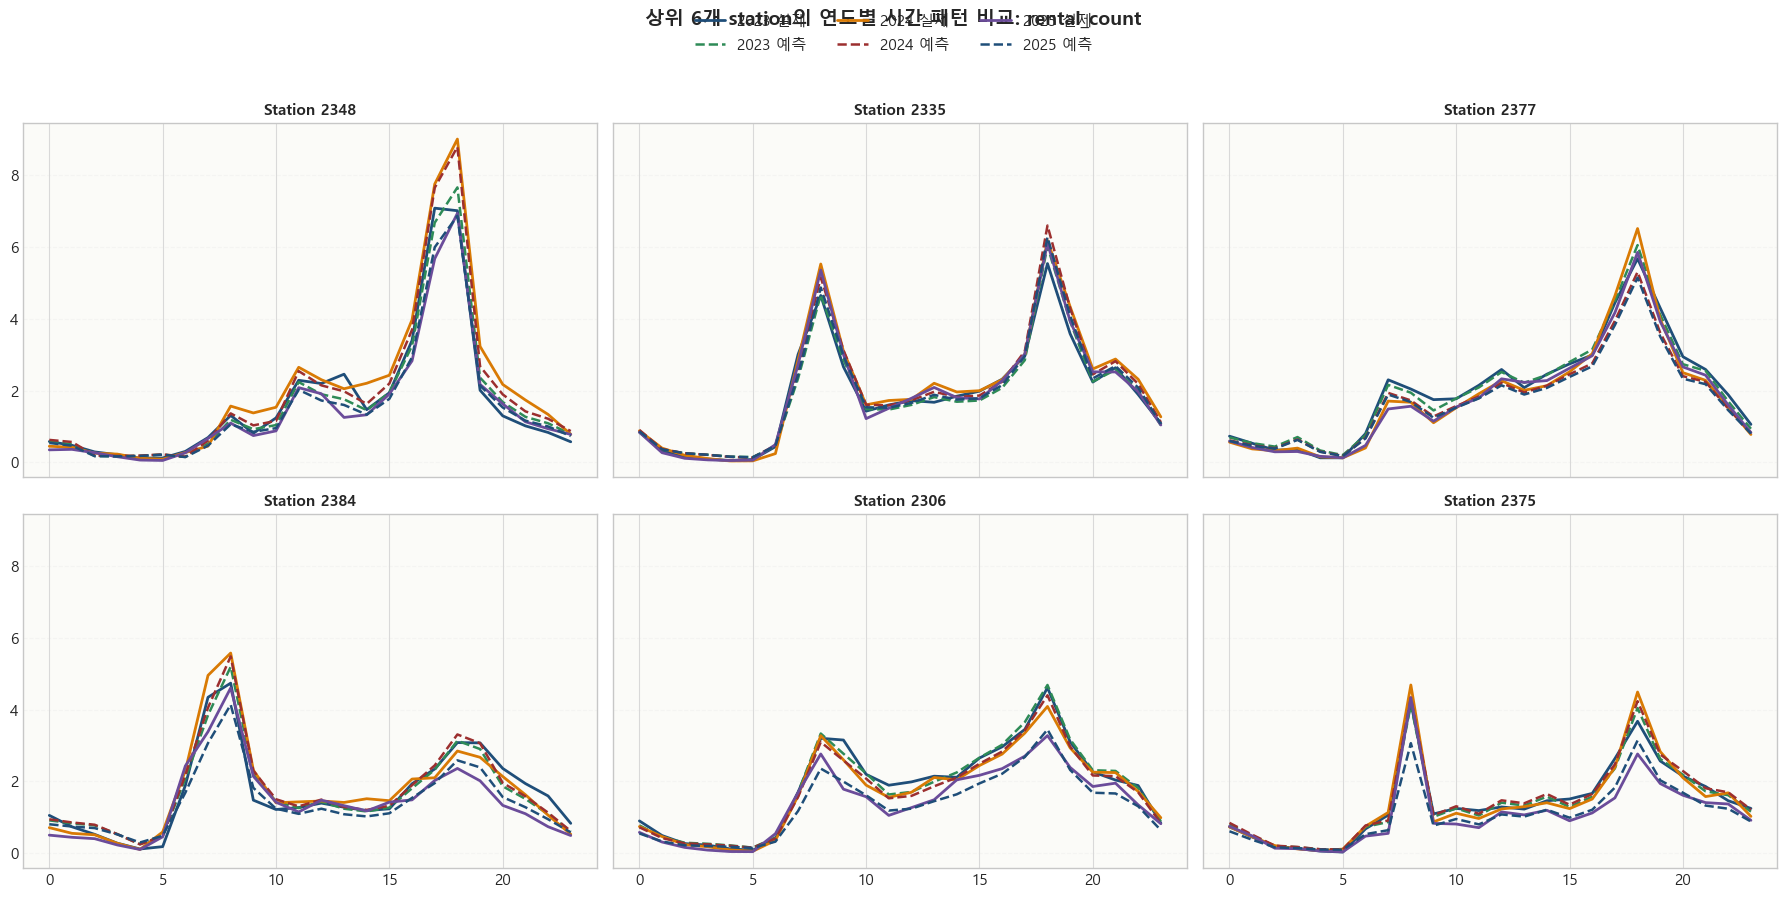

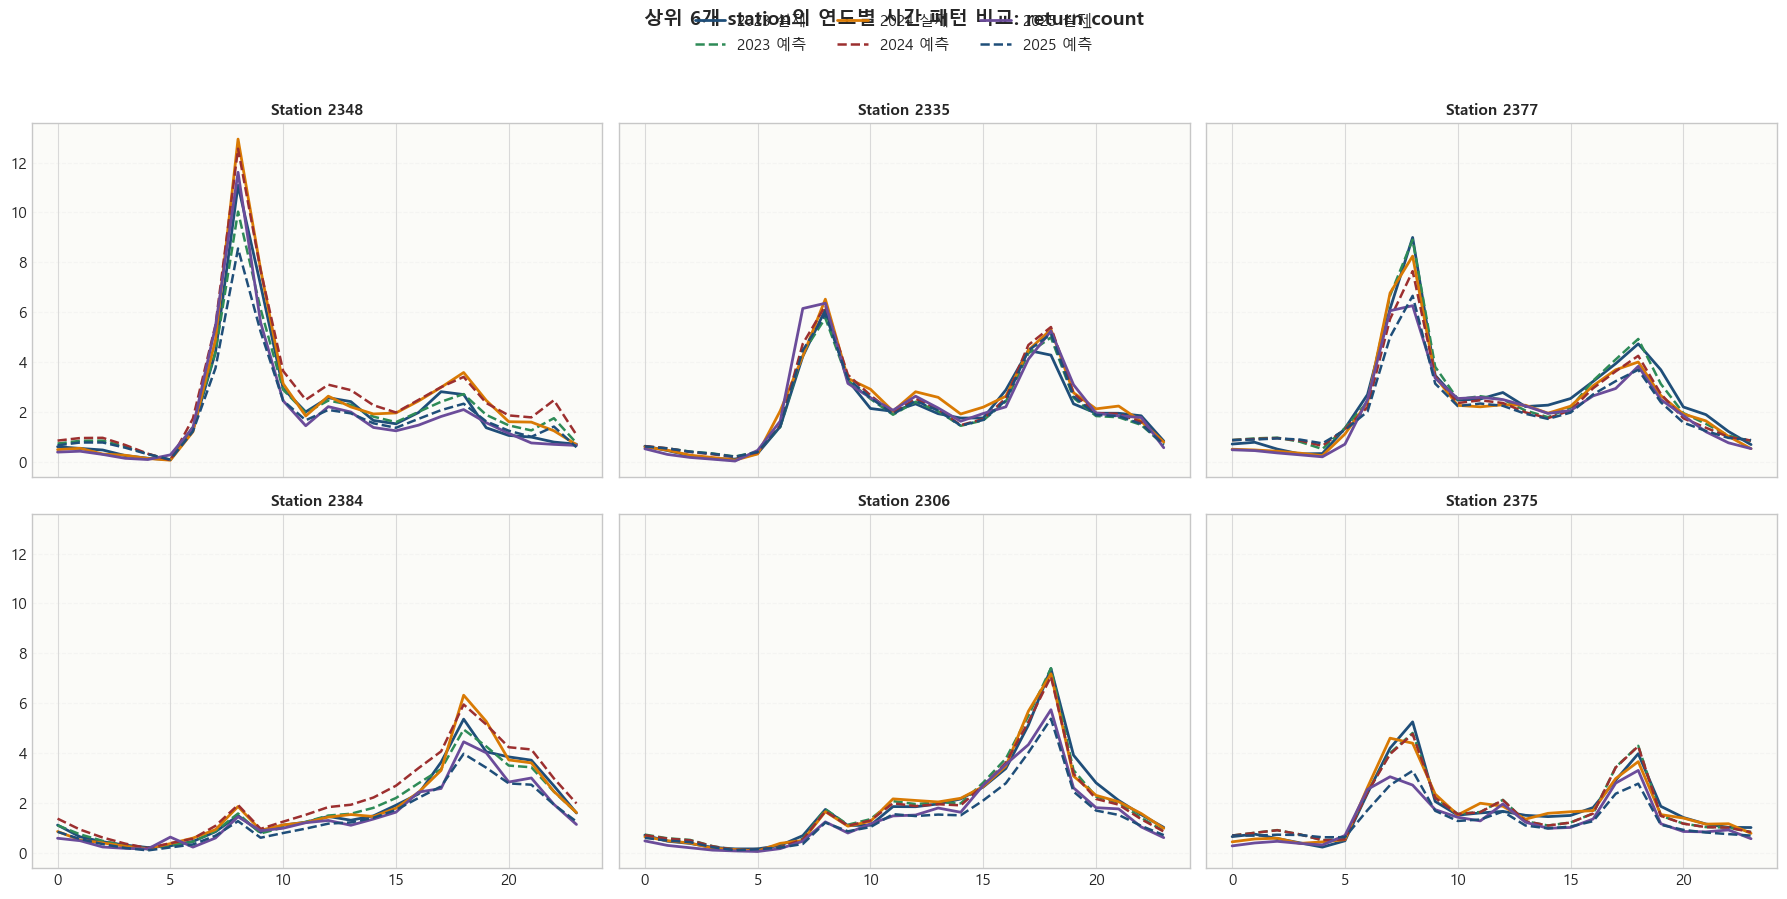

In [22]:
for target in TARGETS:
    target_df = comparison_all_df[(comparison_all_df['target'] == target) & (comparison_all_df['granularity'] == 'hour') & (comparison_all_df['station_id'].isin(top6_station_ids))].copy()
    yearly = (
        target_df.pivot_table(index=['station_id', 'year', 'key'], columns='series', values='value', aggfunc='mean')
        .reset_index()
    )
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, station_id in zip(axes, top6_station_ids):
        station_df = yearly[yearly['station_id'] == station_id]
        for year in sorted(station_df['year'].dropna().unique()):
            part = station_df[station_df['year'] == year]
            ax.plot(part['key'], part['actual_value'], label=f'{int(year)} 실제', linewidth=2.0)
            ax.plot(part['key'], part['prediction'], linestyle='--', label=f'{int(year)} 예측', linewidth=1.8)
        ax.set_title(f'Station {station_id}', fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.18, linestyle='--')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3)
    fig.suptitle(f'상위 6개 station의 연도별 시간 패턴 비교: {target}', y=0.995, fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


,station_id,target,mean_abs_error,max_abs_error,station_label,station_name
0,2306,rental_count,4.2401,11.1931,2306 | 압구정역 2번 출구 옆,압구정역 2번 출구 옆
1,2306,return_count,4.5946,11.8120,2306 | 압구정역 2번 출구 옆,압구정역 2번 출구 옆
2,2335,rental_count,5.1406,11.4570,2335 | 3호선 매봉역 3번출구앞,3호선 매봉역 3번출구앞
3,2335,return_count,5.7814,15.4786,2335 | 3호선 매봉역 3번출구앞,3호선 매봉역 3번출구앞
4,2348,rental_count,5.7146,18.8554,2348 | 포스코사거리(기업은행),포스코사거리(기업은행)
5,2348,return_count,7.3217,28.4262,2348 | 포스코사거리(기업은행),포스코사거리(기업은행)
6,2375,rental_count,3.9818,12.1469,2375 | 수서역 1번출구 앞,수서역 1번출구 앞
7,2375,return_count,4.1761,9.8281,2375 | 수서역 1번출구 앞,수서역 1번출구 앞
8,2377,rental_count,5.6795,18.4003,2377 | 수서역 5번출구,수서역 5번출구
9,2377,return_count,6.0385,16.7125,2377 | 수서역 5번출구,수서역 5번출구


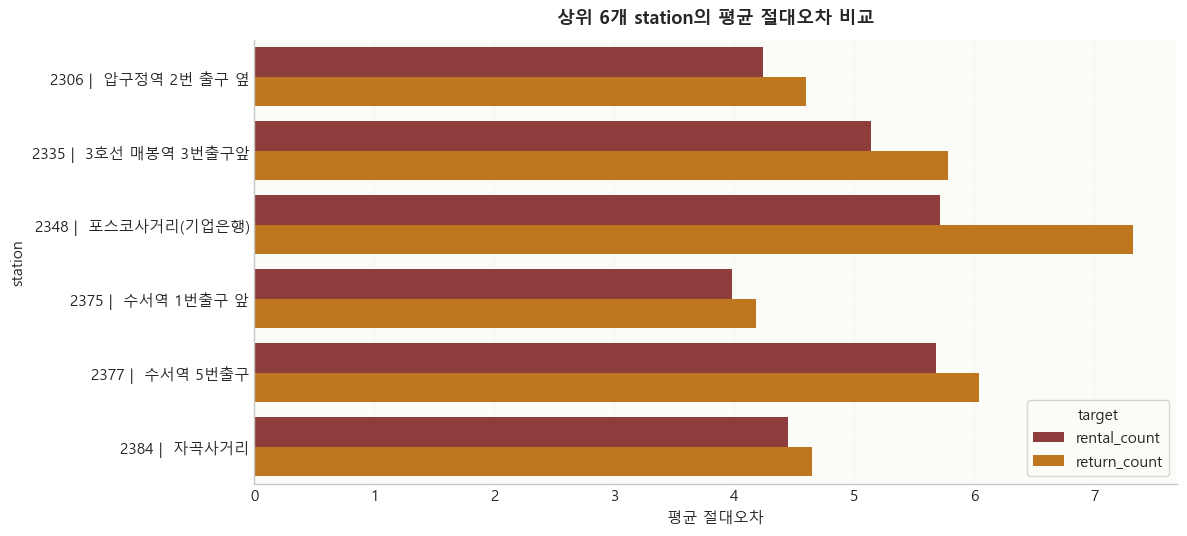

In [23]:
top6_error_df = error_all_df[error_all_df['station_id'].isin(top6_station_ids)].copy()
top6_error_summary_df = (
    top6_error_df.groupby(['station_id', 'target'], as_index=False)
    .agg(
        mean_abs_error=('abs_error', 'mean'),
        max_abs_error=('abs_error', 'max'),
    )
)
top6_error_summary_df = top6_error_summary_df.merge(station_meta_df[['station_id', 'station_label', 'station_name']], on='station_id', how='left')
display(top6_error_summary_df.round(4))

plt.figure(figsize=(12, 5.5))
sns.barplot(data=top6_error_summary_df, x='mean_abs_error', y='station_label', hue='target', palette=['#9c2f2f', '#d97a04'])
format_axis(plt.gca(), '상위 6개 station의 평균 절대오차 비교', '평균 절대오차', 'station')
plt.legend(title='target', frameon=True, loc='lower right')
plt.tight_layout()
plt.show()


## 10. 중요 feature와 오차 진단

단순 랭킹만으로는 모델을 설명하기 어렵기 때문에, 여기서는 모델이 반복적으로 의존한 feature와 2025년에 오차가 많이 발생한 시점을 함께 정리합니다.

In [24]:
importance_summary_df = (
    importance_all_df.groupby(['target', 'feature'], as_index=False)['importance_ratio']
    .mean()
    .sort_values(['target', 'importance_ratio'], ascending=[True, False])
)
importance_summary_df.round(4)


,target,feature,importance_ratio
1,rental_count,corrected_pattern_prior,0.5548
6,rental_count,pattern_prior,0.1575
4,rental_count,hour_weight,0.1406
5,rental_count,month_weight,0.0797
0,rental_count,base_value,0.0497
2,rental_count,day_type_offday,0.0089
3,rental_count,day_type_weekday,0.0089
7,rental_count,year_weight,0.0000
9,return_count,corrected_pattern_prior,0.5494
14,return_count,pattern_prior,0.1490


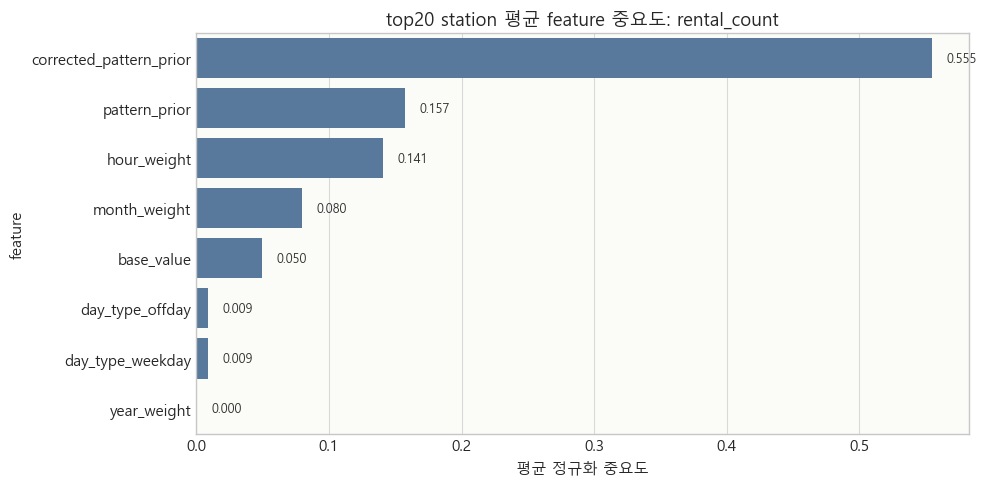

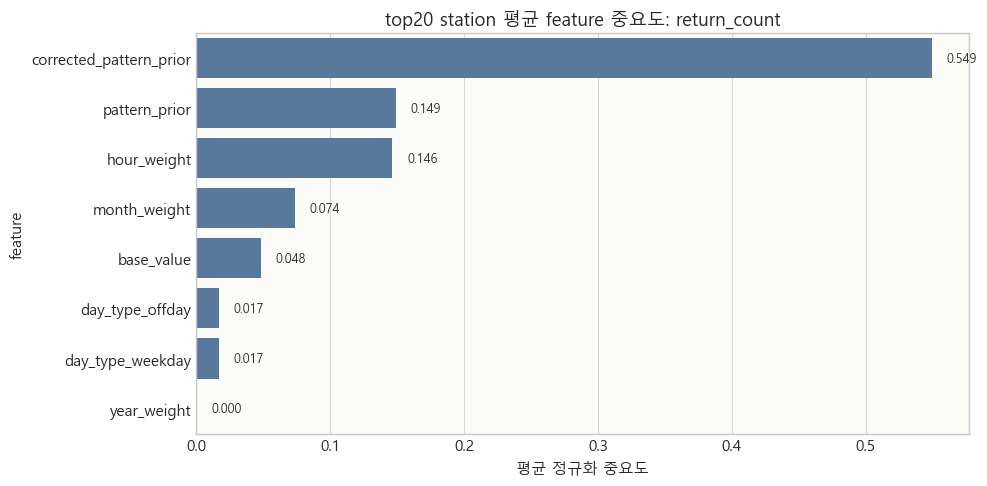

In [25]:
for target in TARGETS:
    target_df = importance_summary_df[importance_summary_df['target'] == target].copy()
    plt.figure(figsize=(10, 5))
    sns.barplot(data=target_df, x='importance_ratio', y='feature', color='#4C78A8')
    plt.title(f'top20 station 평균 feature 중요도: {target}')
    plt.xlabel('평균 정규화 중요도')
    plt.ylabel('feature')
    annotate_barh(plt.gca(), fmt='{:.3f}', pad=0.02)
    plt.tight_layout()
    plt.show()


## 11. 2025 테스트 오차 hotspot

각 station에서 추출한 고오차 시점을 합쳐, 현재 feature 구성으로 설명이 어려운 공통 월과 시간대를 확인합니다.

In [26]:
error_summary_df = (
    error_all_df.groupby(['station_id', 'target'], as_index=False)
    .agg(
        hotspot_count=('abs_error', 'size'),
        mean_abs_error=('abs_error', 'mean'),
        max_abs_error=('abs_error', 'max'),
    )
    .sort_values(['mean_abs_error', 'max_abs_error'], ascending=False)
)
display(error_summary_df.head(12).round(4))

hotspot_time_df = (
    error_all_df.groupby(['target', 'month', 'hour'], as_index=False)
    .agg(
        hotspot_count=('abs_error', 'size'),
        mean_abs_error=('abs_error', 'mean'),
    )
)
hotspot_time_df.sort_values(['target', 'hotspot_count', 'mean_abs_error'], ascending=[True, False, False]).head(20)


,station_id,target,hotspot_count,mean_abs_error,max_abs_error
11,2348,return_count,441,7.3217,28.4262
17,2377,return_count,438,6.0385,16.7125
5,2335,return_count,438,5.7814,15.4786
10,2348,rental_count,438,5.7146,18.8554
16,2377,rental_count,438,5.6795,18.4003
35,3627,return_count,438,5.3062,23.1260
4,2335,rental_count,441,5.1406,11.4570
19,2384,return_count,439,4.6436,10.6281
1,2306,return_count,441,4.5946,11.8120
20,2404,rental_count,438,4.4590,12.9984


,target,month,hour,hotspot_count,mean_abs_error
102,rental_count,5,18,208,4.4500
196,rental_count,9,18,201,4.8006
80,rental_count,4,18,182,4.3585
217,rental_count,10,18,180,4.5707
125,rental_count,6,18,176,4.3927
172,rental_count,8,18,154,4.9307
148,rental_count,7,18,150,4.6537
195,rental_count,9,17,143,4.3238
216,rental_count,10,17,137,4.2035
101,rental_count,5,17,134,4.2246


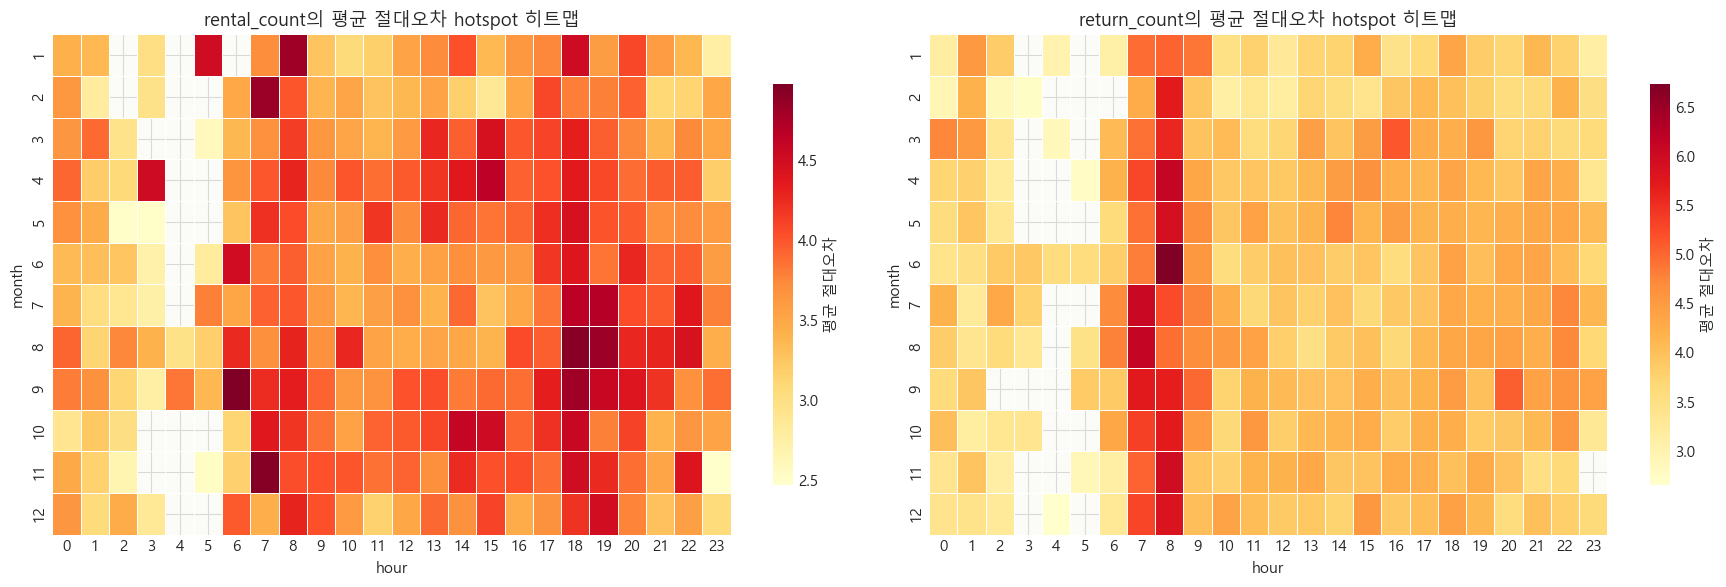

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, target in zip(axes, TARGETS):
    sub = hotspot_time_df[hotspot_time_df['target'] == target]
    pivot = sub.pivot(index='month', columns='hour', values='mean_abs_error').sort_index()
    sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.4, linecolor='white', cbar_kws={'shrink': 0.8, 'label': '평균 절대오차'})
    ax.set_title(f'{target}의 평균 절대오차 hotspot 히트맵')
    ax.set_xlabel('hour')
    ax.set_ylabel('month')
plt.tight_layout()
plt.show()


## 12. 최종 결론

마지막으로 통합 랭킹, 반복적으로 중요한 feature, test hotspot 결과를 한 번에 묶어 요약합니다.

In [28]:
top5_df = ranking_df.head(5)[['station_id', 'combined_test_r2', 'combined_test_rmse', 'combined_test_mae']].copy()
bottom5_df = ranking_df.tail(5)[['station_id', 'combined_test_r2', 'combined_test_rmse', 'combined_test_mae']].copy()
top_feature_df = (
    importance_summary_df.sort_values(['target', 'importance_ratio'], ascending=[True, False])
    .groupby('target', as_index=False)
    .first()[['target', 'feature', 'importance_ratio']]
)
conclusion_summary_df = pd.DataFrame([
    {'item': '통합 test R^2 1위 station', 'value': int(ranking_df.iloc[0]['station_id'])},
    {'item': '1위 station의 통합 test R^2', 'value': float(ranking_df.iloc[0]['combined_test_r2'])},
    {'item': '통합 test R^2 중앙값', 'value': float(ranking_df['combined_test_r2'].median())},
    {'item': '통합 test R^2 최하위 station', 'value': int(ranking_df.iloc[-1]['station_id'])},
    {'item': 'rental_count 공통 핵심 feature', 'value': top_feature_df[top_feature_df['target'] == 'rental_count']['feature'].iloc[0]},
    {'item': 'return_count 공통 핵심 feature', 'value': top_feature_df[top_feature_df['target'] == 'return_count']['feature'].iloc[0]},
])
display(conclusion_summary_df)
display(top5_df.round(4))
display(bottom5_df.round(4))
display(top_feature_df.round(4))

print('해석 가이드')
print('- 통합 점수는 rental_count와 return_count의 test R^2 평균입니다.')
print('- 상위 station일수록 시간대 패턴 재현력이 안정적인 경우가 많습니다.')
print('- 반복적으로 나타나는 hotspot 월과 시간대는 후속 외생 변수 보강 후보입니다.')


,item,value
0,통합 test R^2 1위 station,2348
1,1위 station의 통합 test R^2,0.6144
2,통합 test R^2 중앙값,0.3331
3,통합 test R^2 최하위 station,2423
4,rental_count 공통 핵심 feature,corrected_pattern_prior
5,return_count 공통 핵심 feature,corrected_pattern_prior


,station_id,combined_test_r2,combined_test_rmse,combined_test_mae
1,2348,0.6144,1.9717,1.1505
2,2335,0.5460,1.8061,1.2224
3,2377,0.4556,1.9343,1.3262
4,2384,0.4355,1.5267,1.0654
5,2306,0.4316,1.4738,1.0021


,station_id,combined_test_r2,combined_test_rmse,combined_test_mae
16,4906,0.2878,1.4088,1.0296
17,3614,0.2825,1.2705,0.9257
18,2369,0.2672,1.2202,0.9053
19,2413,0.2537,1.3515,0.9509
20,2423,0.2444,1.3493,0.9971


,target,feature,importance_ratio
0,rental_count,corrected_pattern_prior,0.5548
1,return_count,corrected_pattern_prior,0.5494


해석 가이드
- 통합 점수는 rental_count와 return_count의 test R^2 평균입니다.
- 상위 station일수록 시간대 패턴 재현력이 안정적인 경우가 많습니다.
- 반복적으로 나타나는 hotspot 월과 시간대는 후속 외생 변수 보강 후보입니다.


## 13. 현재 구조에서 재고 예측을 해석하는 방법

현재 모델은 특정 시점의 **총 보유 대수**를 직접 예측하는 구조가 아니라, 각 시간대의 `rental_count`와 `return_count`를 예측하는 구조입니다.

따라서 API 등을 통해 **현재 시점의 실제 자전거 수량**을 알고 있다면, 이후 재고는 다음과 같이 누적 계산할 수 있습니다.

`다음 시점 재고 = 현재 재고 - 예측 rental_count + 예측 return_count`

이 방식은 몇 시간 뒤 또는 하루 이내처럼 **단기 재고 흐름**을 보는 데는 활용할 수 있지만, 며칠 뒤처럼 예측 구간이 길어질수록 대여/반납 예측 오차가 누적되기 때문에 신뢰도가 빠르게 낮아질 수 있습니다.

또한 실제 운영에서는 재배치, 거치대 용량, 돌발 이벤트 같은 요소가 재고에 영향을 주므로, 장기 재고 예측까지 안정적으로 수행하려면 이후에는 `총 재고` 자체를 직접 예측하는 모델이나 재배치/외생 변수까지 포함한 구조로 확장하는 것이 더 적절합니다.

In [29]:
inventory_note_df = pd.DataFrame([
    {'구분': '현재 모델의 직접 예측값', '설명': '시간대별 rental_count, return_count'},
    {'구분': '재고 계산 방식', '설명': '현재 재고 - 예측 대여량 + 예측 반납량의 누적 합'},
    {'구분': '상대적으로 적합한 범위', '설명': '몇 시간 뒤 ~ 하루 이내의 단기 재고 흐름'},
    {'구분': '주의가 필요한 범위', '설명': '며칠 후 재고처럼 누적 오차가 커지는 장기 예측'},
    {'구분': '오차 확대 요인', '설명': '재배치, 거치대 한계, 이벤트, 날씨 급변, 시간 누적 오차'},
])
inventory_note_df


,구분,설명
0,현재 모델의 직접 예측값,"시간대별 rental_count, return_count"
1,재고 계산 방식,현재 재고 - 예측 대여량 + 예측 반납량의 누적 합
2,상대적으로 적합한 범위,몇 시간 뒤 ~ 하루 이내의 단기 재고 흐름
3,주의가 필요한 범위,며칠 후 재고처럼 누적 오차가 커지는 장기 예측
4,오차 확대 요인,"재배치, 거치대 한계, 이벤트, 날씨 급변, 시간 누적 오차"
